In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


import time
import math
import random
import re
import os
import sys


from utils.util import find_files_with_extension
from utils.util import  get_dataframe_from_filepath,calculate_statistics, extract_unique_mbps_and_ms
from utils.util import remove_outliers_iqr, comma_format, create_directory_if_not_exists,print_rtt_stats,save_rtt_stats,return_rtt_stats

In [3]:
# Load data
mainpth="../data/udp_data_2025-04-11"

graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

stats_directory = os.path.join(mainpth, "Stats")
create_directory_if_not_exists(stats_directory)


folderpaths = [mainpth+'/client1_data',mainpth+'/client2_data']
filenames, filepaths, filedict = find_files_with_extension(folderpaths, '.log')


Directory already exists: ../data/udp_data_2025-04-11\Graphs
Directory already exists: ../data/udp_data_2025-04-11\Stats


In [4]:
filedict

{'1_dualpi2_100Mbps_0ms_ecn_udp_newreno_src1.siftr.log': '../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_0ms_ecn_udp_newreno_src1.siftr.log',
 '1_dualpi2_100Mbps_10ms_ecn_udp_newreno_src1.siftr.log': '../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_10ms_ecn_udp_newreno_src1.siftr.log',
 '1_dualpi2_100Mbps_20ms_ecn_udp_newreno_src1.siftr.log': '../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_20ms_ecn_udp_newreno_src1.siftr.log',
 '1_dualpi2_100Mbps_5ms_ecn_udp_newreno_src1.siftr.log': '../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_5ms_ecn_udp_newreno_src1.siftr.log',
 '1_dualpi2_10Mbps_0ms_ecn_udp_newreno_src1.siftr.log': '../data/udp_data_2025-04-11/client1_data\\1_dualpi2_10Mbps_0ms_ecn_udp_newreno_src1.siftr.log',
 '1_dualpi2_10Mbps_10ms_ecn_udp_newreno_src1.siftr.log': '../data/udp_data_2025-04-11/client1_data\\1_dualpi2_10Mbps_10ms_ecn_udp_newreno_src1.siftr.log',
 '1_dualpi2_10Mbps_20ms_ecn_udp_newreno_src1.siftr.log': '../data/ud

In [5]:
folderpaths

['../data/udp_data_2025-04-11/client1_data',
 '../data/udp_data_2025-04-11/client2_data']

In [6]:
# Call the function and print unique combinations
unique_combinations = extract_unique_mbps_and_ms(folderpaths)
print("Unique Mbps and ms Combinations:")
for mbps, ms in sorted(unique_combinations):
    print(f'{mbps} Mbps, {ms} ms')


Unique Mbps and ms Combinations:
10 Mbps, 0 ms
10 Mbps, 10 ms
10 Mbps, 20 ms
10 Mbps, 5 ms
100 Mbps, 0 ms
100 Mbps, 10 ms
100 Mbps, 20 ms
100 Mbps, 5 ms
150 Mbps, 0 ms
150 Mbps, 10 ms
150 Mbps, 20 ms
150 Mbps, 5 ms
20 Mbps, 0 ms
20 Mbps, 10 ms
20 Mbps, 20 ms
20 Mbps, 5 ms


In [7]:
mbps , ms = list(unique_combinations)[0]
net_settings = f'{mbps}_Mbps_{ms}_ms'
print(net_settings)

20_Mbps_10_ms


In [8]:
df=get_dataframe_from_filepath(filepaths[0])
df['ForeignPort'].unique()

../data/udp_data_2025-04-11/client1_data\1_dualpi2_100Mbps_0ms_ecn_udp_newreno_src1.siftr.log


array(['50530', '50462', '50457', '50463'], dtype=object)

In [9]:
unique_scenarios_dict={}
for index in range(len(filenames)):
    scenario = "_".join(filenames[index].split('_')[:5])
    if "l4s" in scenario:
        scenario = "_".join(filenames[index].split('_')[:4])
    if scenario in unique_scenarios_dict:
        unique_scenarios_dict[scenario].append(filedict[filenames[index]])
    else:
        unique_scenarios_dict[scenario]=[filedict[filenames[index]]]


In [10]:
unique_scenarios_dict

{'1_dualpi2_100Mbps_0ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_0ms_ecn_udp_newreno_src1.siftr.log',
  '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_10ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_10ms_ecn_udp_newreno_src1.siftr.log',
  '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_20ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_20ms_ecn_udp_newreno_src1.siftr.log',
  '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_5ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_5ms_ecn_udp_newreno_src1.siftr.log',
  '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log'],
 '1_dualpi2_10Mbps_0ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2

In [11]:
from utils.plotter import  plot_siftr_graph

In [17]:
unique_scenarios_dict

{'1_dualpi2_100Mbps_0ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_0ms_ecn_udp_newreno_src1.siftr.log',
  '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_10ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_10ms_ecn_udp_newreno_src1.siftr.log',
  '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_20ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_20ms_ecn_udp_newreno_src1.siftr.log',
  '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_5ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_5ms_ecn_udp_newreno_src1.siftr.log',
  '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log'],
 '1_dualpi2_10Mbps_0ms_ecn': ['../data/udp_data_2025-04-11/client1_data\\1_dualpi2


Start New Scenario
1_dualpi2_100Mbps_0ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_0ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
75             o   8.107142  192.168.1.3     45671  192.168.3.2        5102   
76             o   8.107286  192.168.1.3     45671  192.168.3.2        5102   
78             o   8.107934  192.168.1.3     45671  192.168.3.2        5102   
79             o   8.108049  192.168.1.3     45671  192.168.3.2        5102   
82             o   8.109416  192.168.1.3     45671  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
326659    

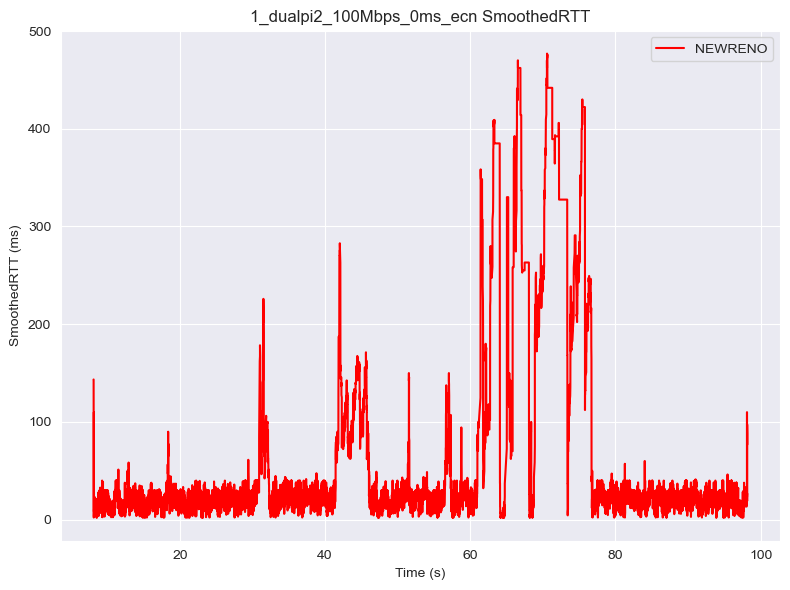

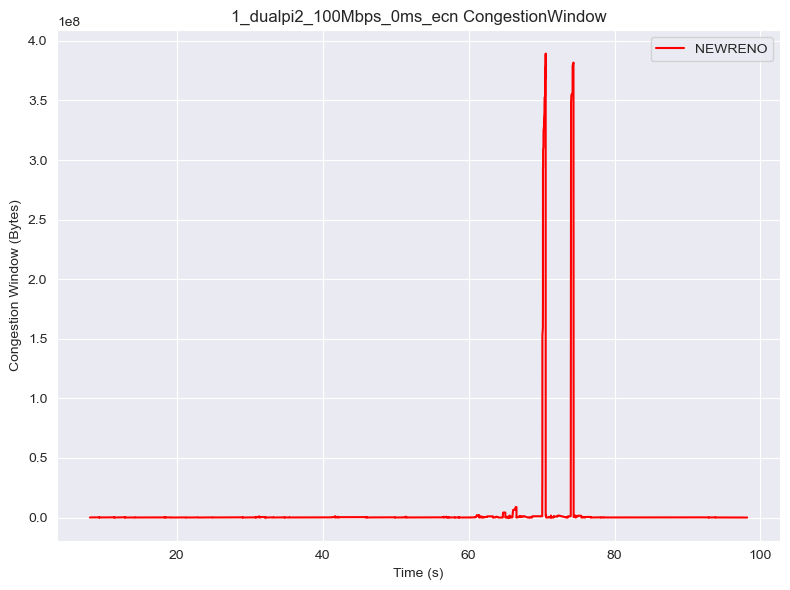


Start New Scenario
1_dualpi2_100Mbps_10ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_10ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
73             o   8.260789  192.168.1.3     21936  192.168.3.2        5102   
74             o   8.260958  192.168.1.3     21936  192.168.3.2        5102   
76             o   8.340766  192.168.1.3     21936  192.168.3.2        5102   
77             o   8.340815  192.168.1.3     21936  192.168.3.2        5102   
80             o   8.460698  192.168.1.3     21936  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
30745

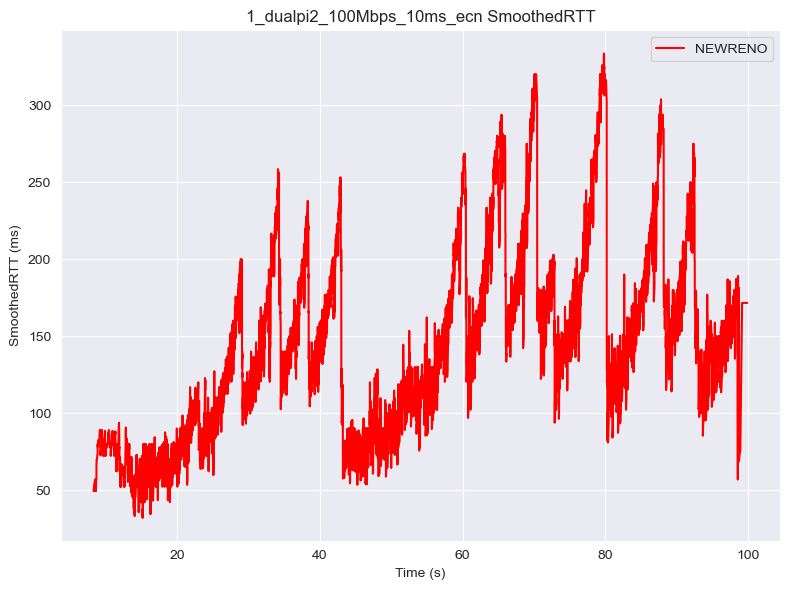

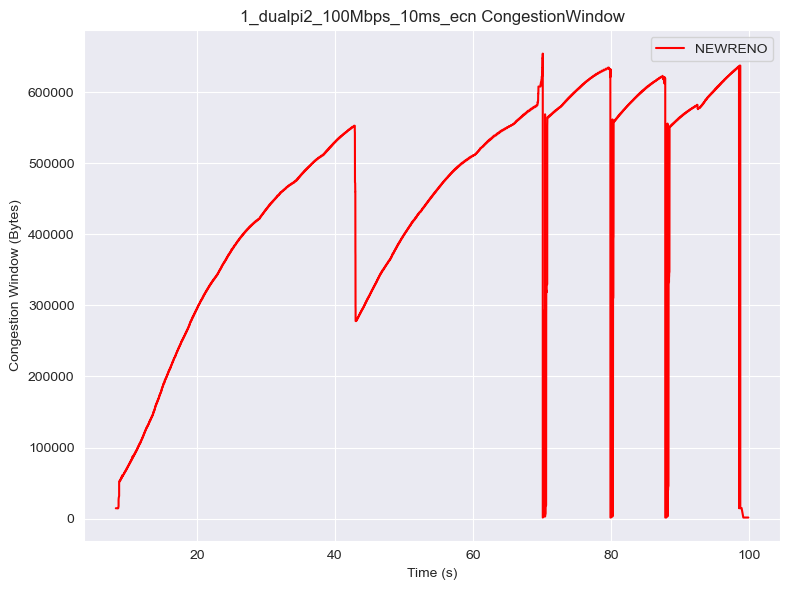


Start New Scenario
1_dualpi2_100Mbps_20ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_20ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
73             o   8.092284  192.168.1.3     51008  192.168.3.2        5102   
74             o   8.092347  192.168.1.3     51008  192.168.3.2        5102   
76             o   8.182414  192.168.1.3     51008  192.168.3.2        5102   
77             o   8.182453  192.168.1.3     51008  192.168.3.2        5102   
80             o   8.351982  192.168.1.3     51008  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
27155

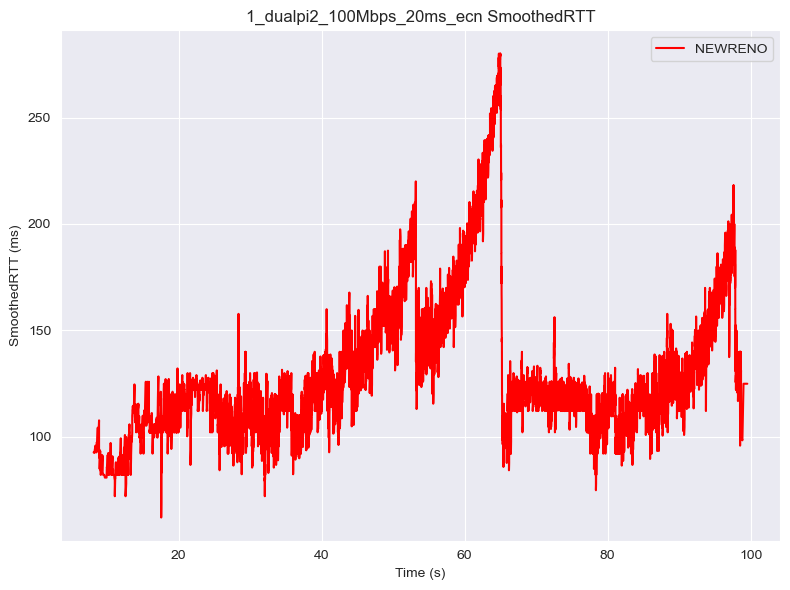

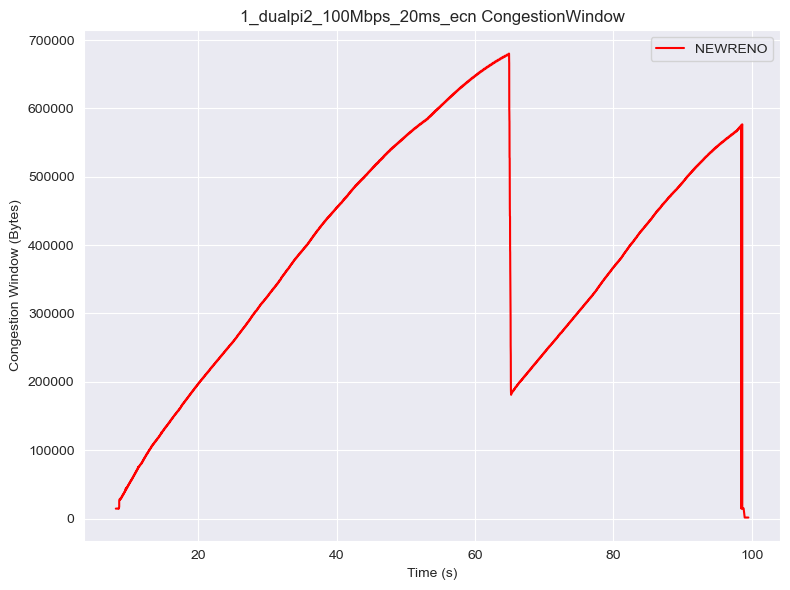


Start New Scenario
1_dualpi2_100Mbps_5ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_100Mbps_5ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
75             o   8.195028  192.168.1.3     45705  192.168.3.2        5102   
76             o   8.195218  192.168.1.3     45705  192.168.3.2        5102   
78             o   8.197762  192.168.1.3     45705  192.168.3.2        5102   
79             o   8.197908  192.168.1.3     45705  192.168.3.2        5102   
82             o   8.201366  192.168.1.3     45705  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
322985    

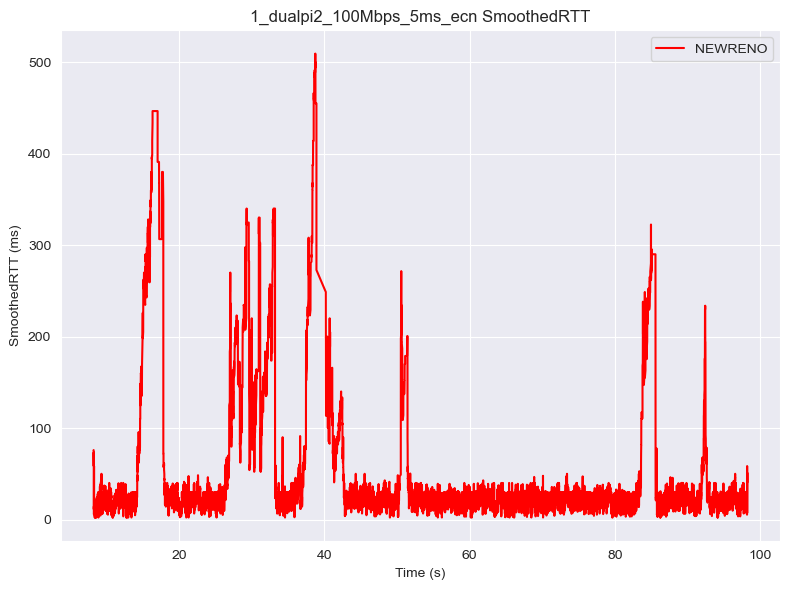

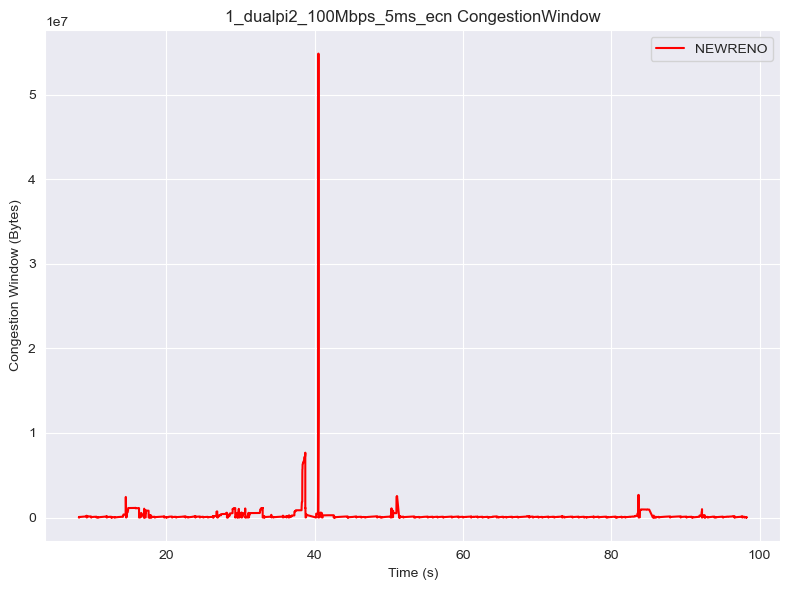


Start New Scenario
1_dualpi2_10Mbps_0ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_10Mbps_0ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_10Mbps_0ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
72            o   8.208956  192.168.1.3     12553  192.168.3.2        5102   
73            o   8.209058  192.168.1.3     12553  192.168.3.2        5102   
75            o   8.209665  192.168.1.3     12553  192.168.3.2        5102   
76            o   8.209768  192.168.1.3     12553  192.168.3.2        5102   
79            o   8.222337  192.168.1.3     12553  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
16225         o  98.58

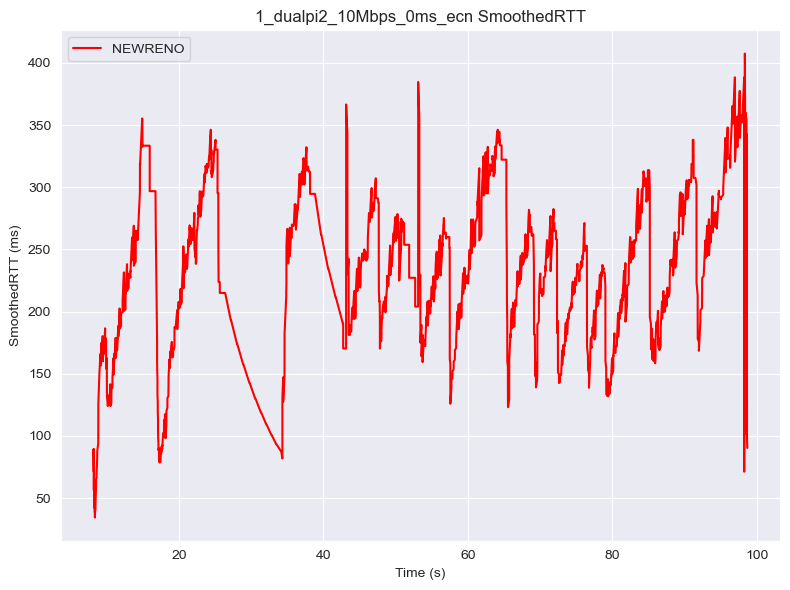

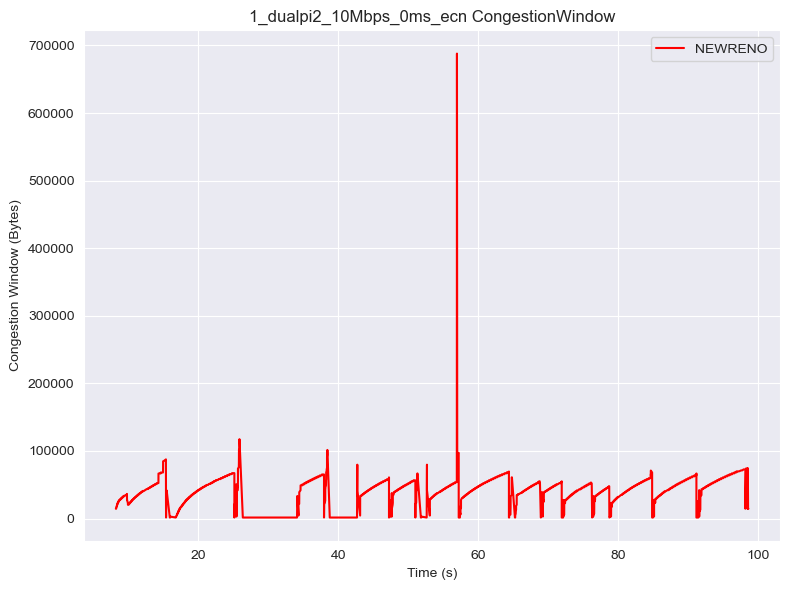


Start New Scenario
1_dualpi2_10Mbps_10ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_10Mbps_10ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_10Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
72            o   8.168239  192.168.1.3     19978  192.168.3.2        5102   
73            o   8.168378  192.168.1.3     19978  192.168.3.2        5102   
75            o   8.248205  192.168.1.3     19978  192.168.3.2        5102   
76            o   8.248350  192.168.1.3     19978  192.168.3.2        5102   
79            o   8.365283  192.168.1.3     19978  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
17704         o  

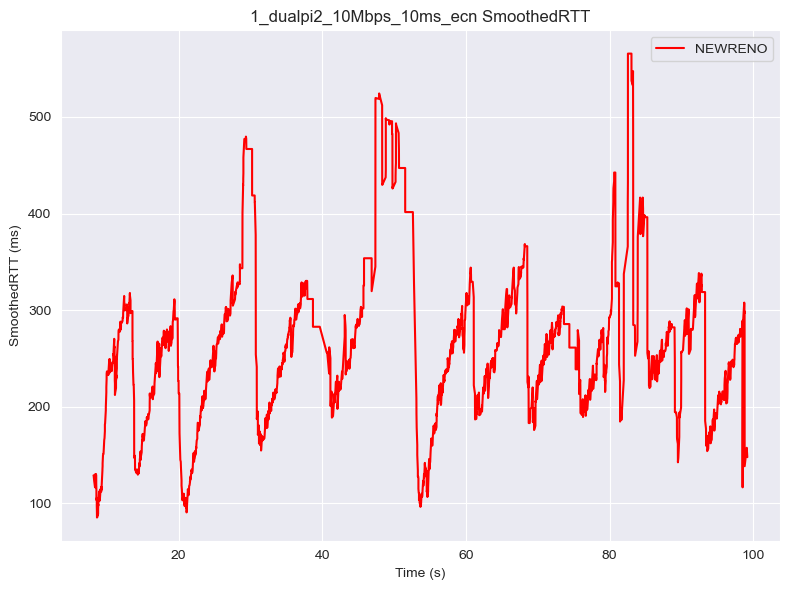

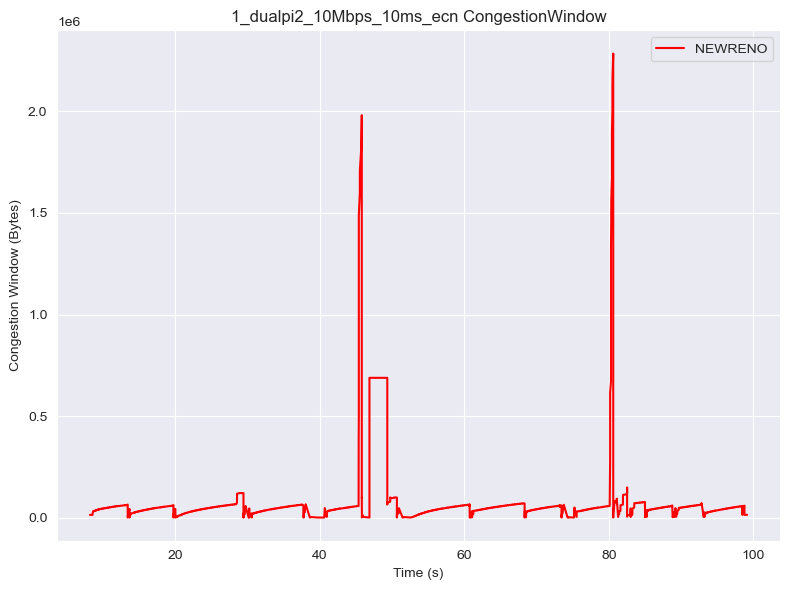


Start New Scenario
1_dualpi2_10Mbps_20ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_10Mbps_20ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_10Mbps_20ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
74            o   8.072976  192.168.1.3     36323  192.168.3.2        5102   
75            o   8.073131  192.168.1.3     36323  192.168.3.2        5102   
77            o   8.192834  192.168.1.3     36323  192.168.3.2        5102   
78            o   8.192957  192.168.1.3     36323  192.168.3.2        5102   
81            o   8.340205  192.168.1.3     36323  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
18127         o  

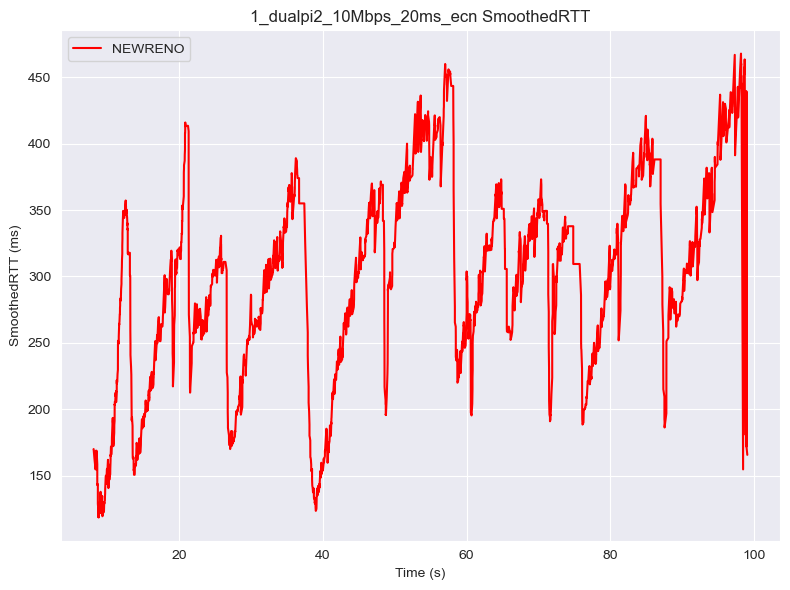

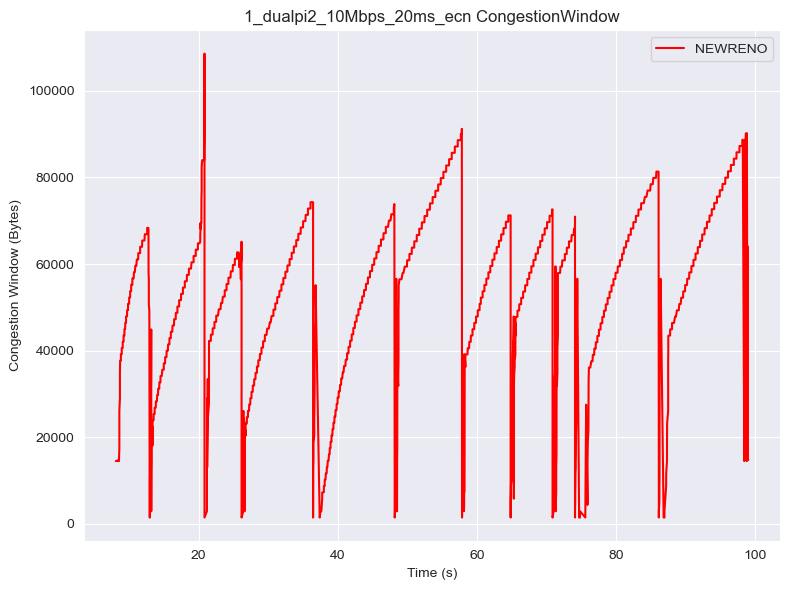


Start New Scenario
1_dualpi2_10Mbps_5ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_10Mbps_5ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_10Mbps_5ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_10Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
75            o   8.217829  192.168.1.3     57978  192.168.3.2        5102   
76            o   8.217958  192.168.1.3     57978  192.168.3.2        5102   
78            o   8.218533  192.168.1.3     57978  192.168.3.2        5102   
79            o   8.218647  192.168.1.3     57978  192.168.3.2        5102   
82            o   8.220011  192.168.1.3     57978  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
17799         o  98.40

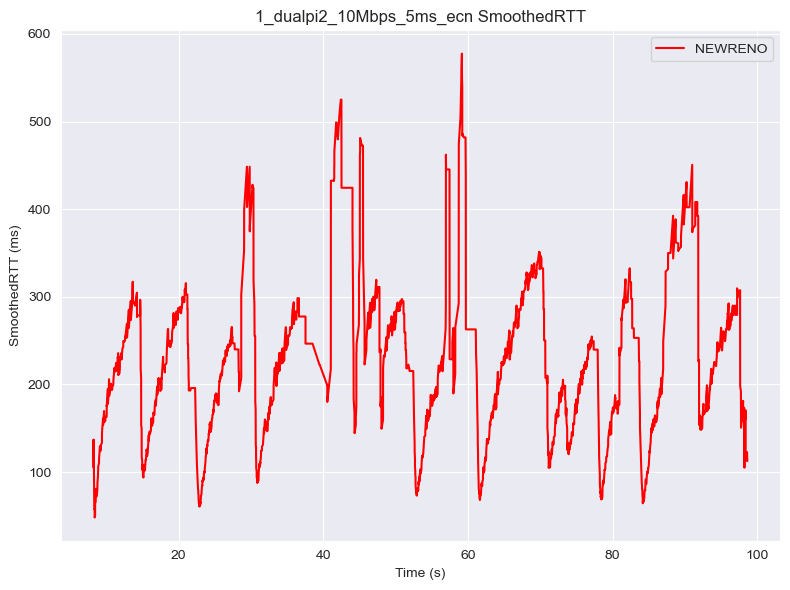

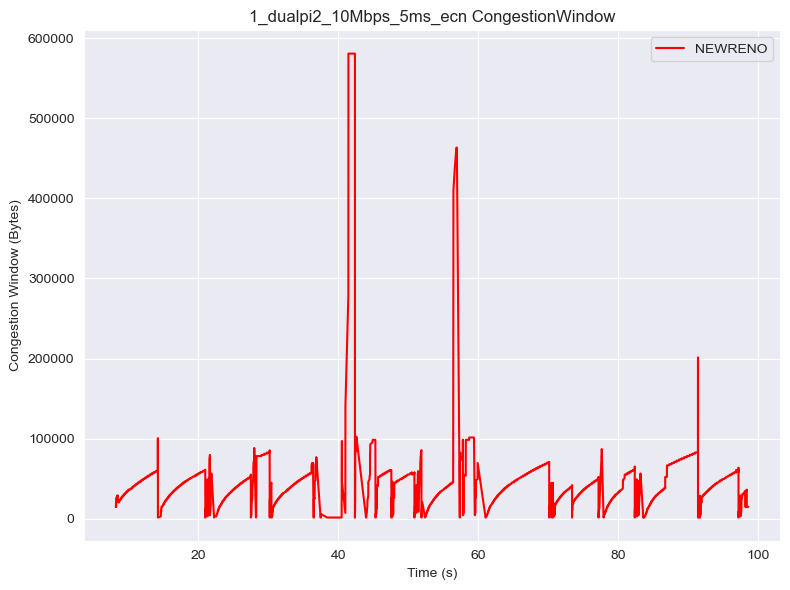


Start New Scenario
1_dualpi2_150Mbps_0ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_150Mbps_0ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_150Mbps_0ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
72             o   8.091745  192.168.1.3     61200  192.168.3.2        5102   
73             o   8.091880  192.168.1.3     61200  192.168.3.2        5102   
75             o   8.092921  192.168.1.3     61200  192.168.3.2        5102   
76             o   8.093041  192.168.1.3     61200  192.168.3.2        5102   
79             o   8.094611  192.168.1.3     61200  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
580820    

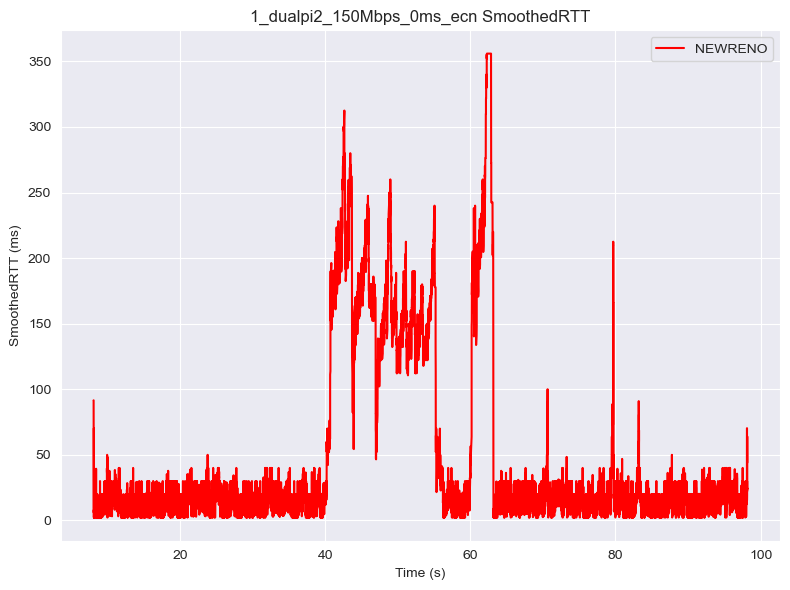

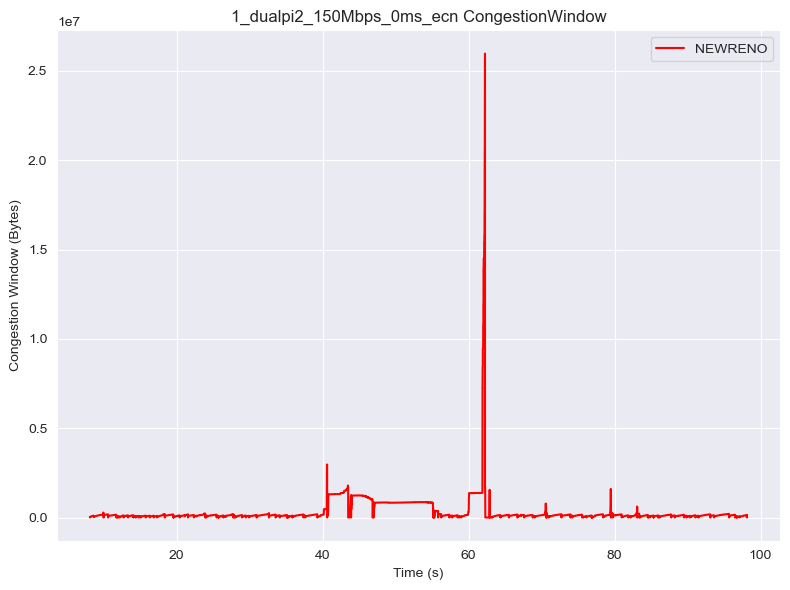


Start New Scenario
1_dualpi2_150Mbps_10ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_150Mbps_10ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_150Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
73             o   8.095023  192.168.1.3     10433  192.168.3.2        5102   
74             o   8.095166  192.168.1.3     10433  192.168.3.2        5102   
76             o   8.169646  192.168.1.3     10433  192.168.3.2        5102   
77             o   8.169795  192.168.1.3     10433  192.168.3.2        5102   
80             o   8.287669  192.168.1.3     10433  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
54468

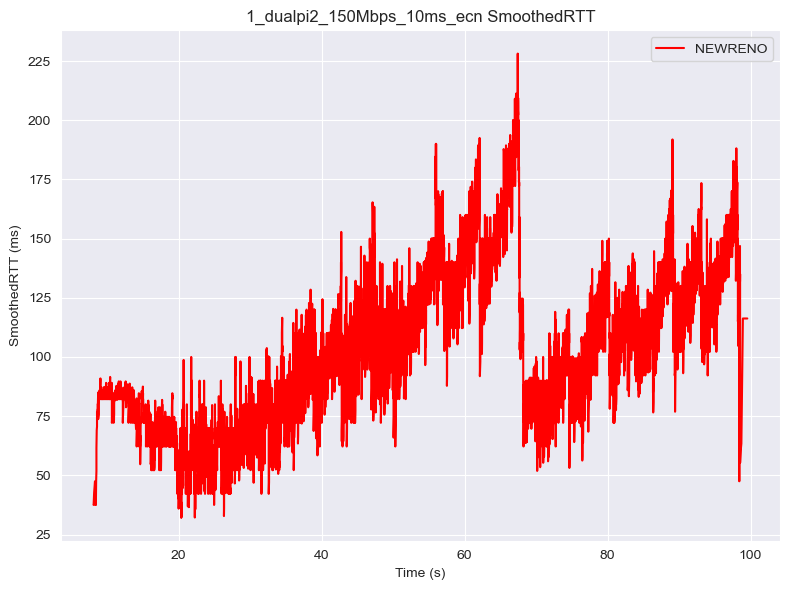

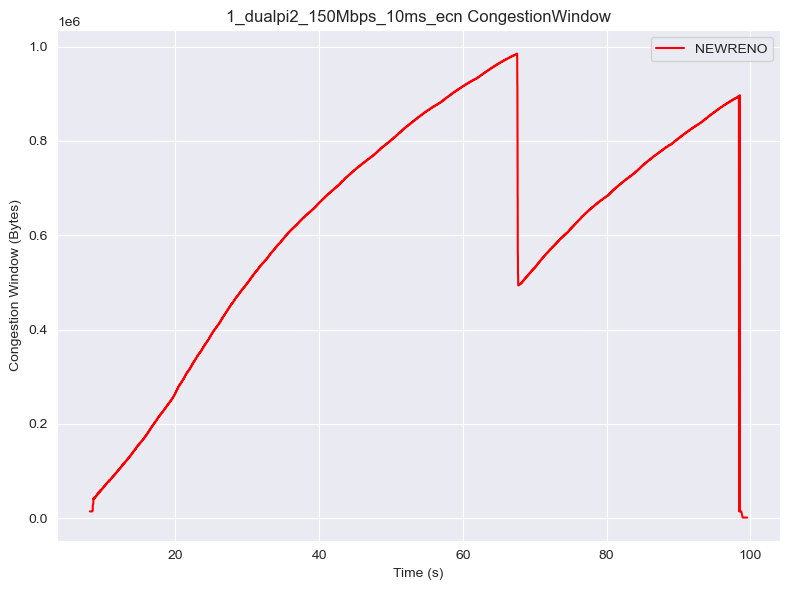


Start New Scenario
1_dualpi2_150Mbps_20ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_150Mbps_20ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_150Mbps_20ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
73             o   8.317065  192.168.1.3     57128  192.168.3.2        5102   
74             o   8.317454  192.168.1.3     57128  192.168.3.2        5102   
76             o   8.425782  192.168.1.3     57128  192.168.3.2        5102   
77             o   8.425830  192.168.1.3     57128  192.168.3.2        5102   
80             o   8.565743  192.168.1.3     57128  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
46154

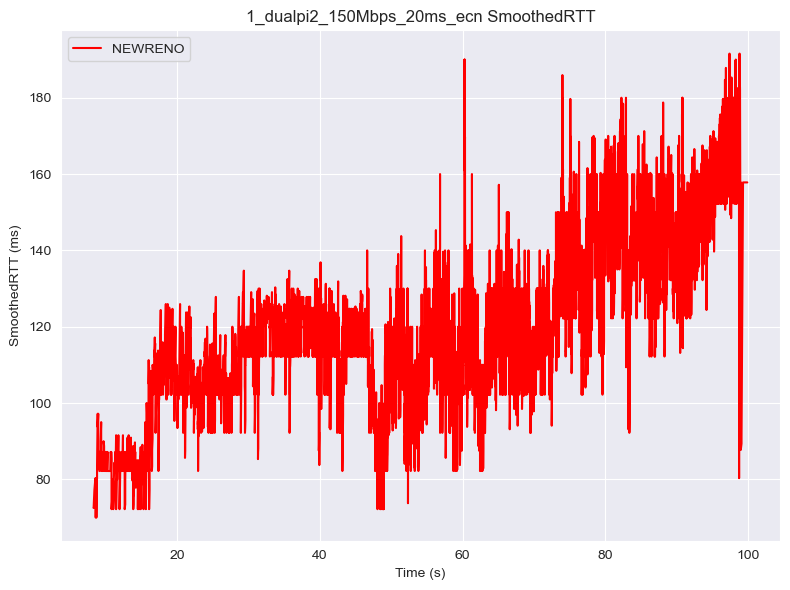

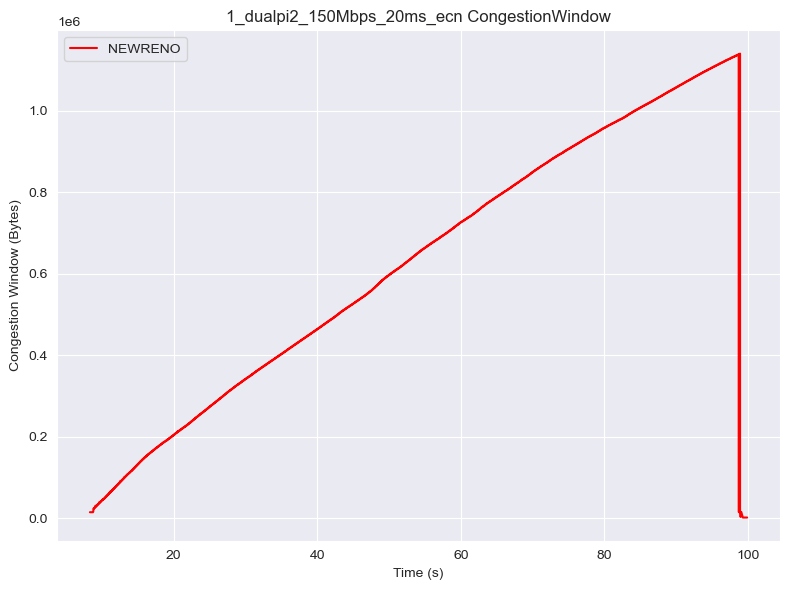


Start New Scenario
1_dualpi2_150Mbps_5ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_150Mbps_5ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_150Mbps_5ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_150Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
72             o   8.209586  192.168.1.3     10674  192.168.3.2        5102   
73             o   8.209644  192.168.1.3     10674  192.168.3.2        5102   
75             o   8.210496  192.168.1.3     10674  192.168.3.2        5102   
76             o   8.210525  192.168.1.3     10674  192.168.3.2        5102   
79             o   8.211579  192.168.1.3     10674  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
608038    

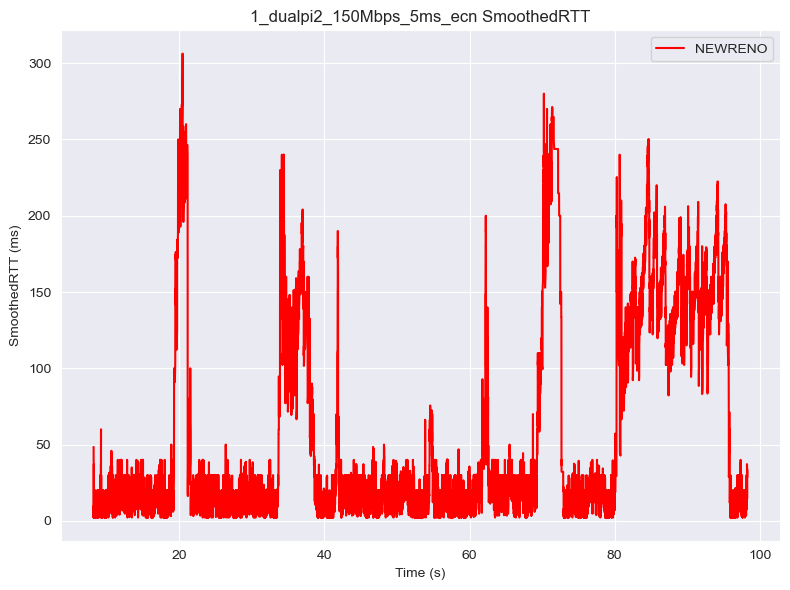

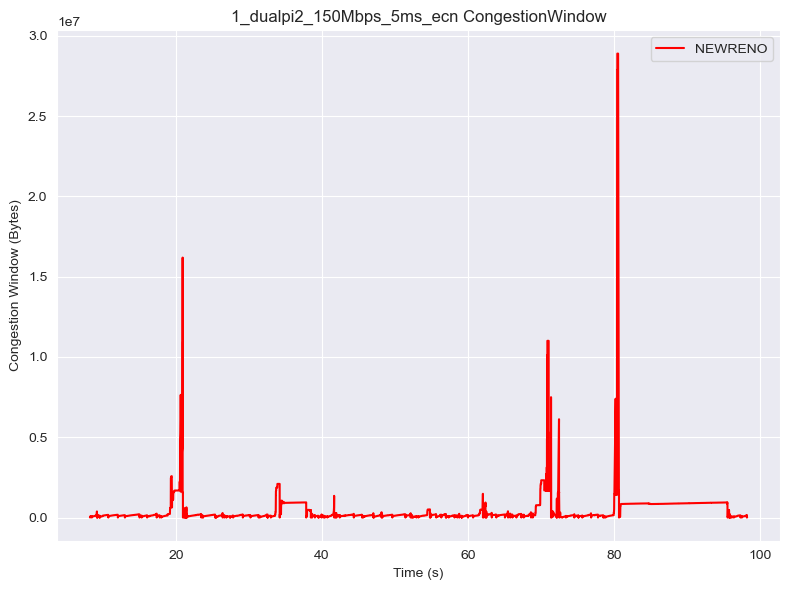


Start New Scenario
1_dualpi2_20Mbps_0ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_20Mbps_0ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
75            o   8.156295  192.168.1.3     43176  192.168.3.2        5102   
76            o   8.156406  192.168.1.3     43176  192.168.3.2        5102   
78            o   8.156931  192.168.1.3     43176  192.168.3.2        5102   
79            o   8.156959  192.168.1.3     43176  192.168.3.2        5102   
82            o   8.158160  192.168.1.3     43176  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
38353         o  98.43

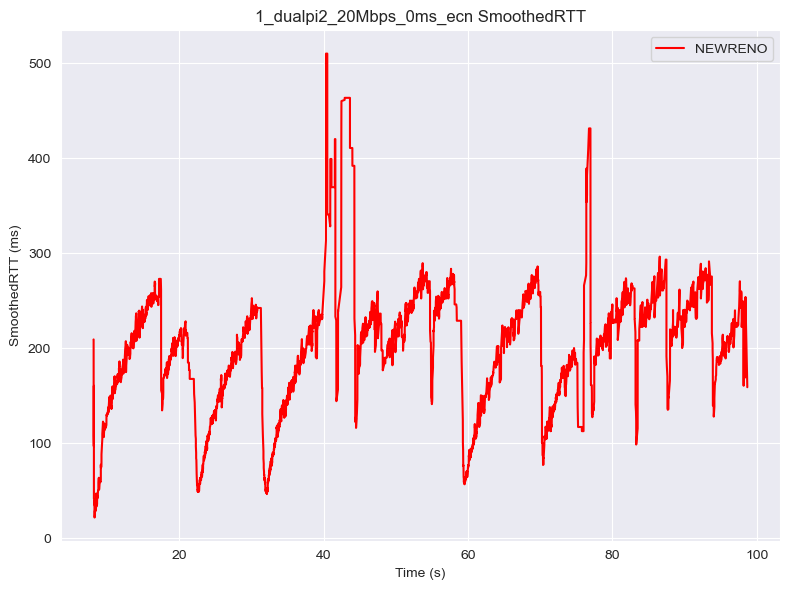

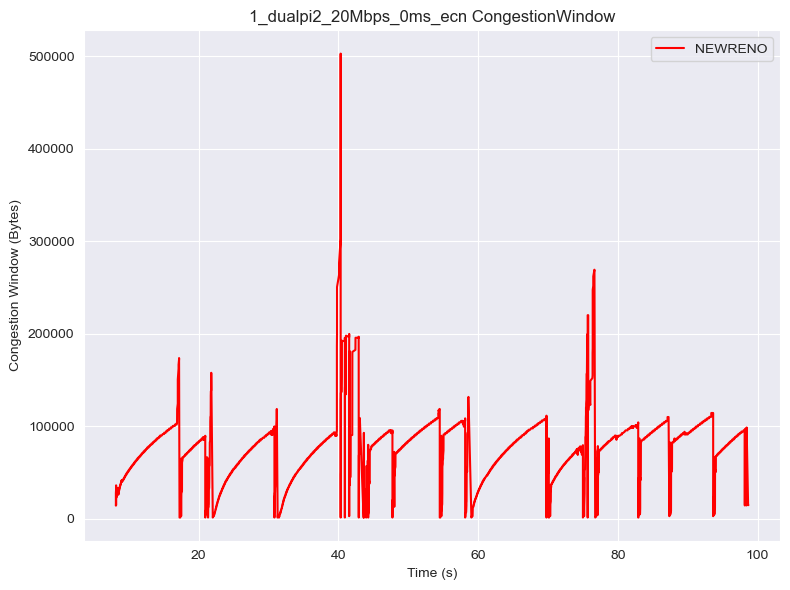


Start New Scenario
1_dualpi2_20Mbps_10ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_20Mbps_10ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_20Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_20Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_20Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
76            o   8.157877  192.168.1.3     52233  192.168.3.2        5102   
77            o   8.158240  192.168.1.3     52233  192.168.3.2        5102   
79            o   8.238547  192.168.1.3     52233  192.168.3.2        5102   
80            o   8.238903  192.168.1.3     52233  192.168.3.2        5102   
83            o   8.397511  192.168.1.3     52233  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
37444         o  

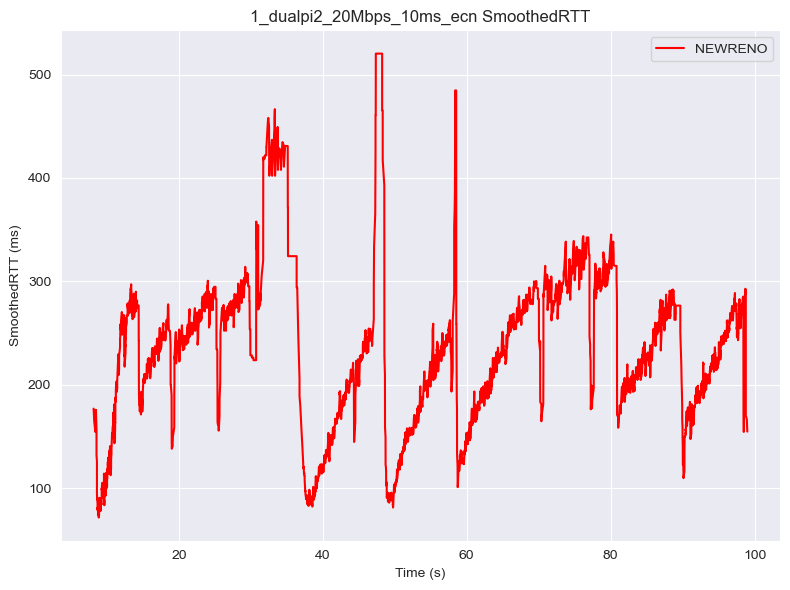

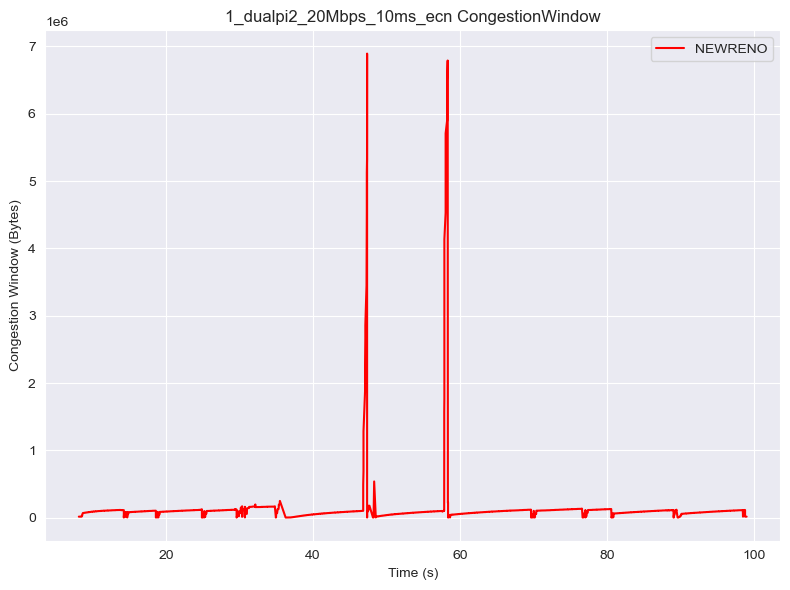


Start New Scenario
1_dualpi2_20Mbps_20ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_20Mbps_20ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_20Mbps_20ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_20Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_20Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
77            o   8.234603  192.168.1.3     21141  192.168.3.2        5102   
78            o   8.234722  192.168.1.3     21141  192.168.3.2        5102   
80            o   8.359422  192.168.1.3     21141  192.168.3.2        5102   
81            o   8.359545  192.168.1.3     21141  192.168.3.2        5102   
84            o   8.508379  192.168.1.3     21141  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
37055         o  

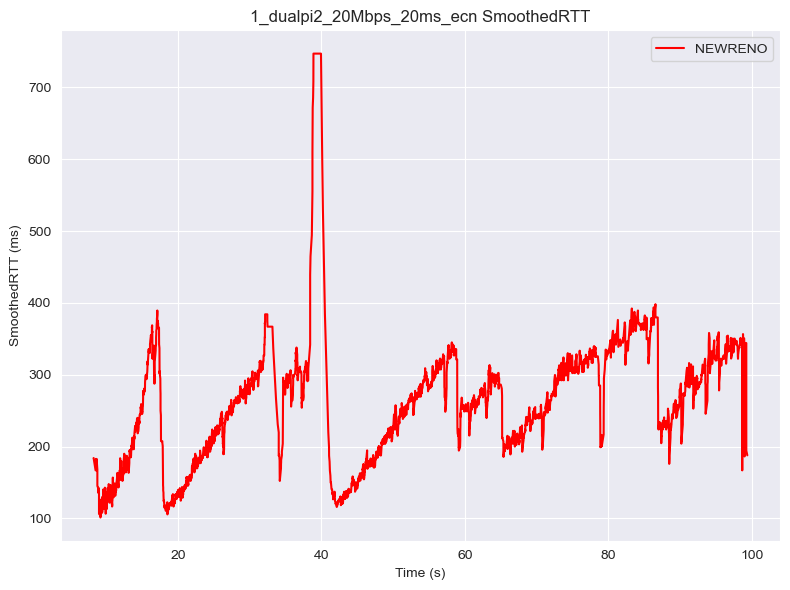

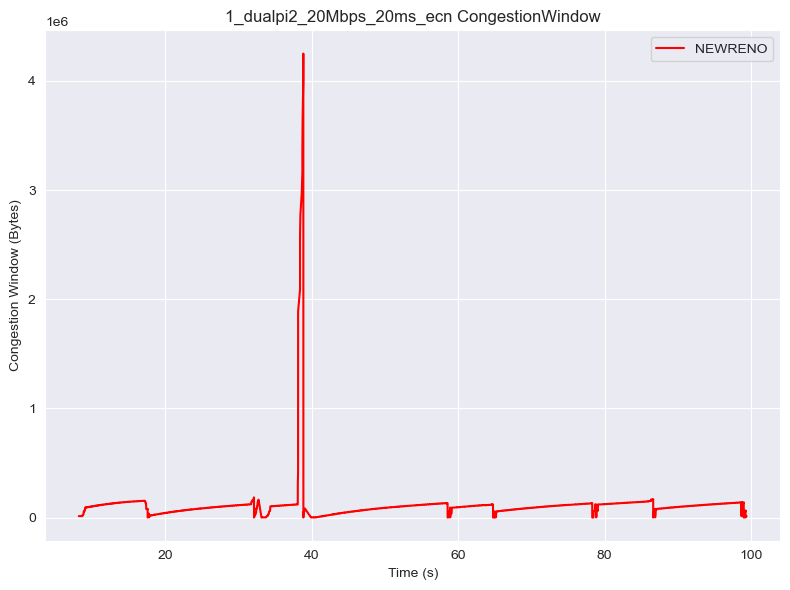


Start New Scenario
1_dualpi2_20Mbps_5ms_ecn
['../data/udp_data_2025-04-11/client1_data\\1_dualpi2_20Mbps_5ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\1_dualpi2_20Mbps_5ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\1_dualpi2_20Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\1_dualpi2_20Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
75            o   8.097933  192.168.1.3     22121  192.168.3.2        5102   
76            o   8.098017  192.168.1.3     22121  192.168.3.2        5102   
78            o   8.099240  192.168.1.3     22121  192.168.3.2        5102   
79            o   8.099378  192.168.1.3     22121  192.168.3.2        5102   
82            o   8.101398  192.168.1.3     22121  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
36937         o  98.56

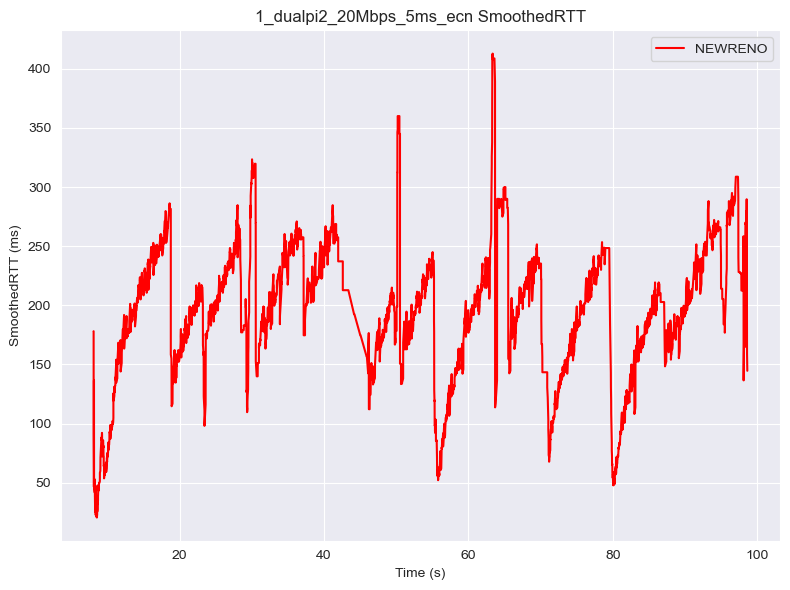

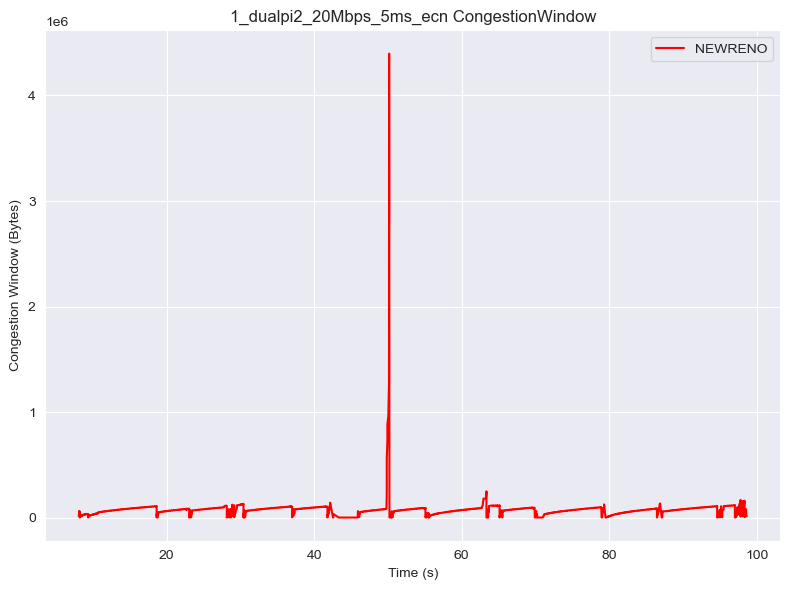


Start New Scenario
2_dualpi2_100Mbps_0ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_100Mbps_0ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
74            o   8.040708  192.168.1.3     61797  192.168.3.2        5102   
75            o   8.040824  192.168.1.3     61797  192.168.3.2        5102   
77            o   8.041494  192.168.1.3     61797  192.168.3.2        5102   
78            o   8.041605  192.168.1.3     61797  192.168.3.2        5102   
81            o   8.042860  192.168.1.3     61797  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
91945         o  

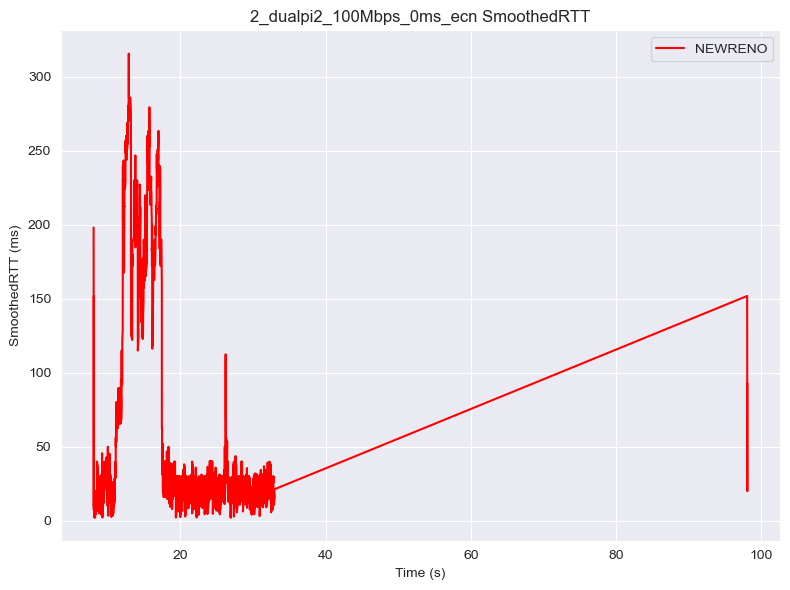

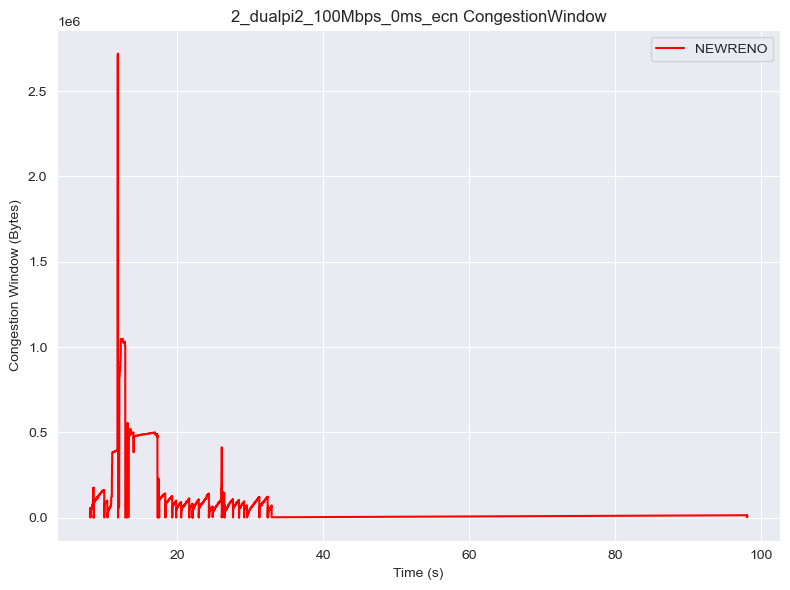


Start New Scenario
2_dualpi2_100Mbps_10ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_100Mbps_10ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
73             o   8.159228  192.168.1.3     28866  192.168.3.2        5102   
74             o   8.159372  192.168.1.3     28866  192.168.3.2        5102   
76             o   8.238420  192.168.1.3     28866  192.168.3.2        5102   
77             o   8.238539  192.168.1.3     28866  192.168.3.2        5102   
80             o   8.399831  192.168.1.3     28866  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
28601

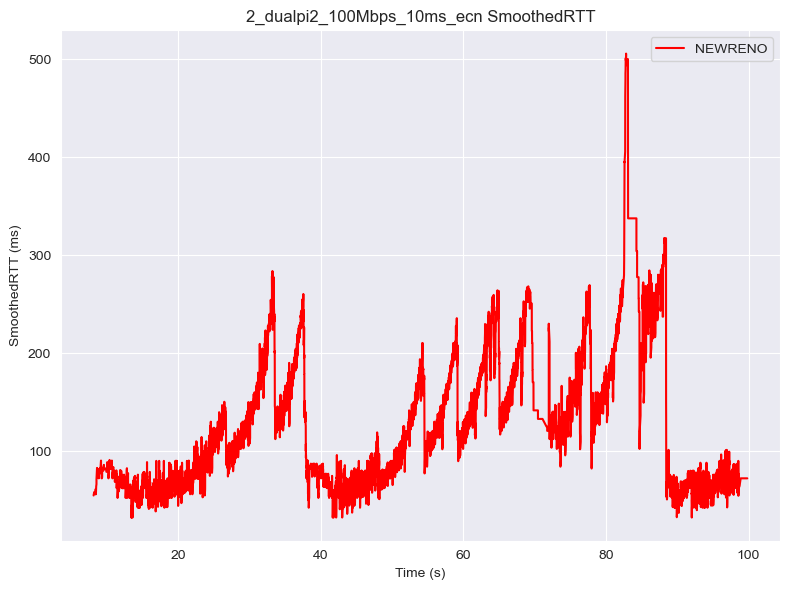

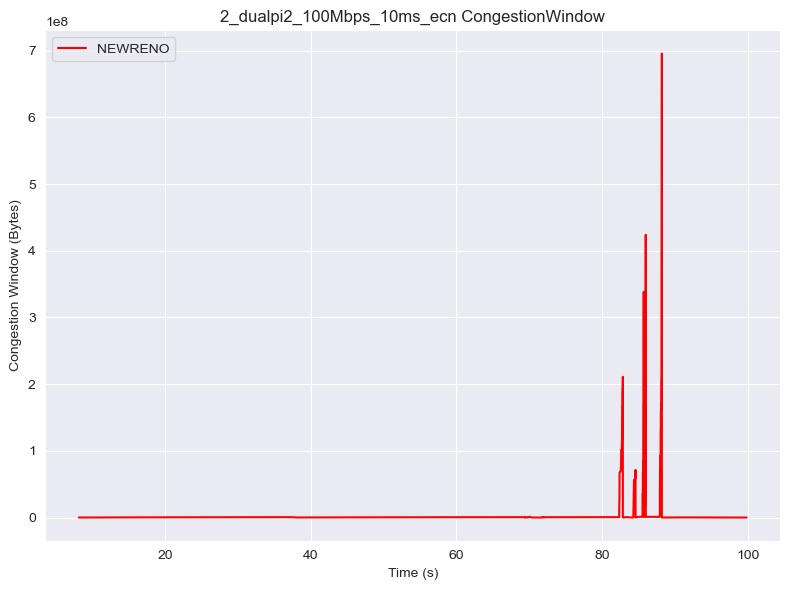


Start New Scenario
2_dualpi2_100Mbps_20ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_100Mbps_20ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
       Direction        Time      LocalIP LocalPort    ForeignIP ForeignPort  \
73             o    8.163204  192.168.1.3     24463  192.168.3.2        5102   
74             o    8.163435  192.168.1.3     24463  192.168.3.2        5102   
76             o    8.273117  192.168.1.3     24463  192.168.3.2        5102   
77             o    8.273304  192.168.1.3     24463  192.168.3.2        5102   
80             o    8.422777  192.168.1.3     24463  192.168.3.2        5102   
...          ...         ...          ...       ...          ...         ...  

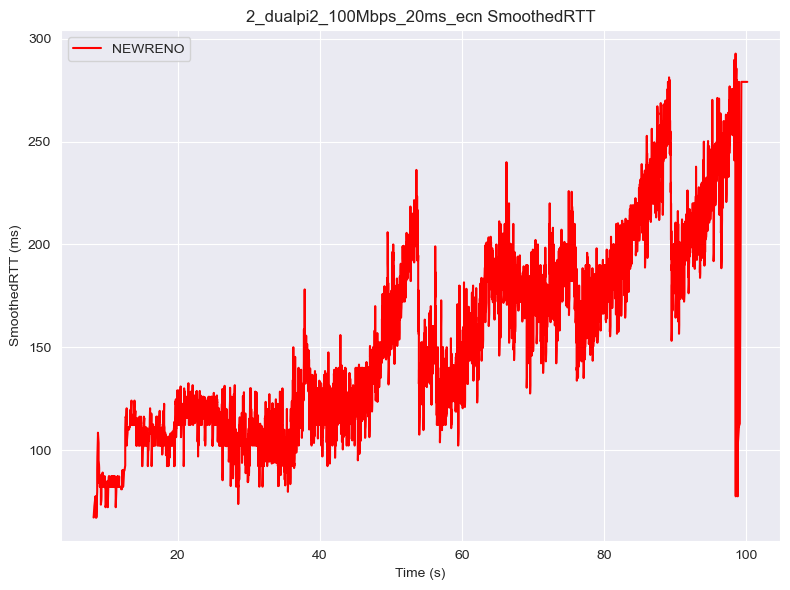

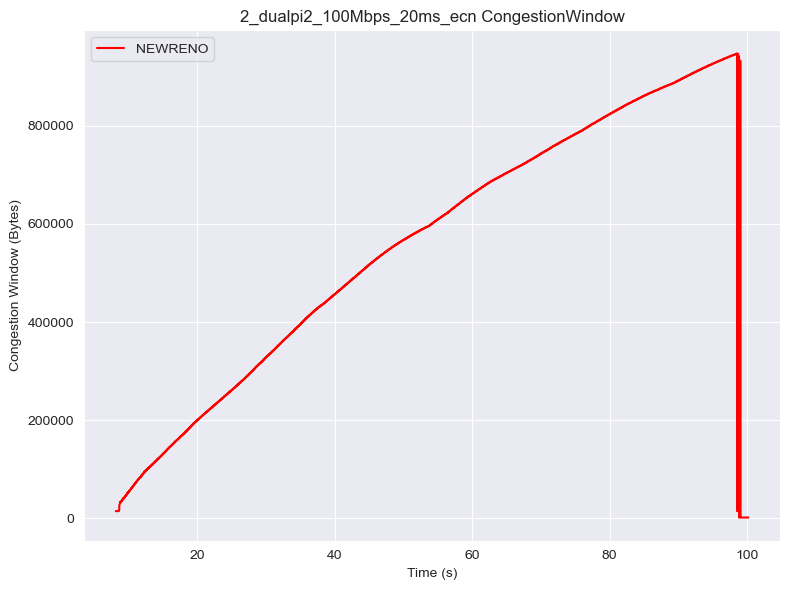


Start New Scenario
2_dualpi2_100Mbps_5ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_100Mbps_5ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
72             o   8.125011  192.168.1.3     39332  192.168.3.2        5102   
73             o   8.125120  192.168.1.3     39332  192.168.3.2        5102   
75             o   8.125632  192.168.1.3     39332  192.168.3.2        5102   
76             o   8.125738  192.168.1.3     39332  192.168.3.2        5102   
79             o   8.127791  192.168.1.3     39332  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
338837    

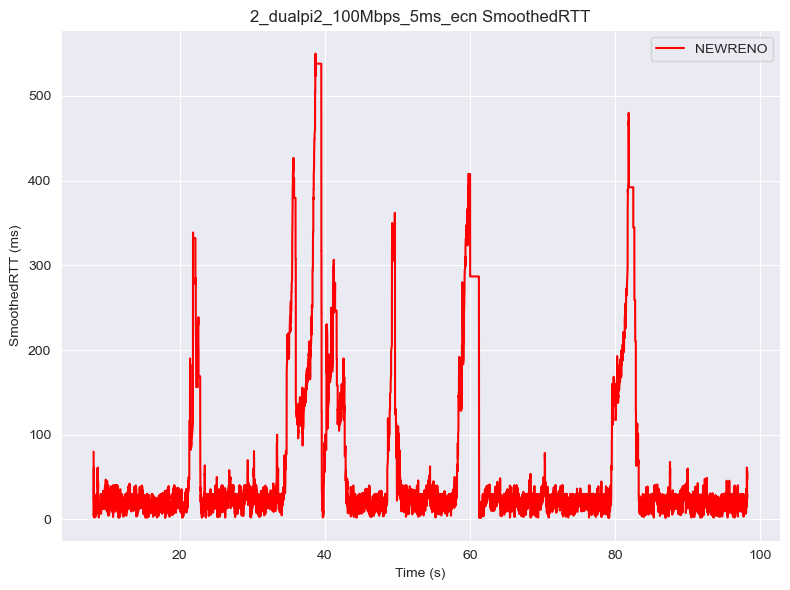

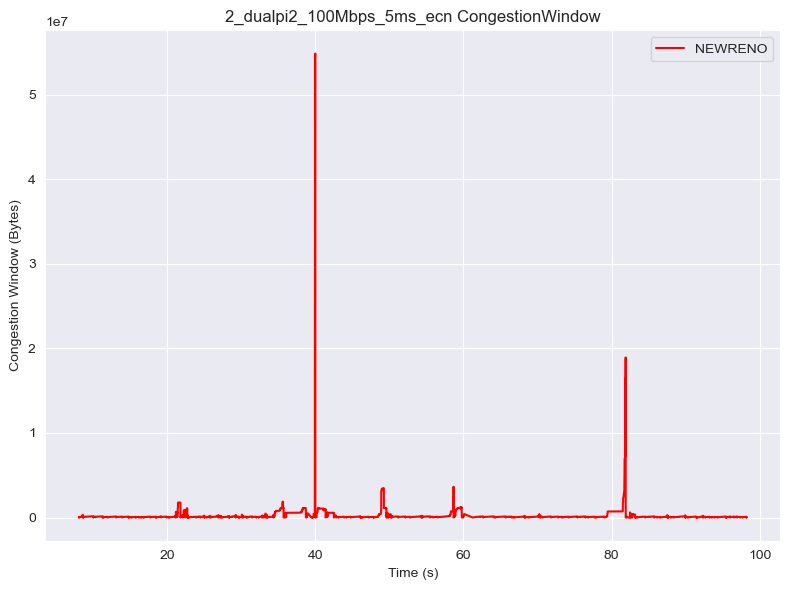


Start New Scenario
2_dualpi2_10Mbps_0ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_10Mbps_0ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_10Mbps_0ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_10Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_10Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
72            o   8.217726  192.168.1.3     53732  192.168.3.2        5102   
73            o   8.217873  192.168.1.3     53732  192.168.3.2        5102   
75            o   8.219096  192.168.1.3     53732  192.168.3.2        5102   
76            o   8.219216  192.168.1.3     53732  192.168.3.2        5102   
79            o   8.221671  192.168.1.3     53732  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
14962         o  98.50

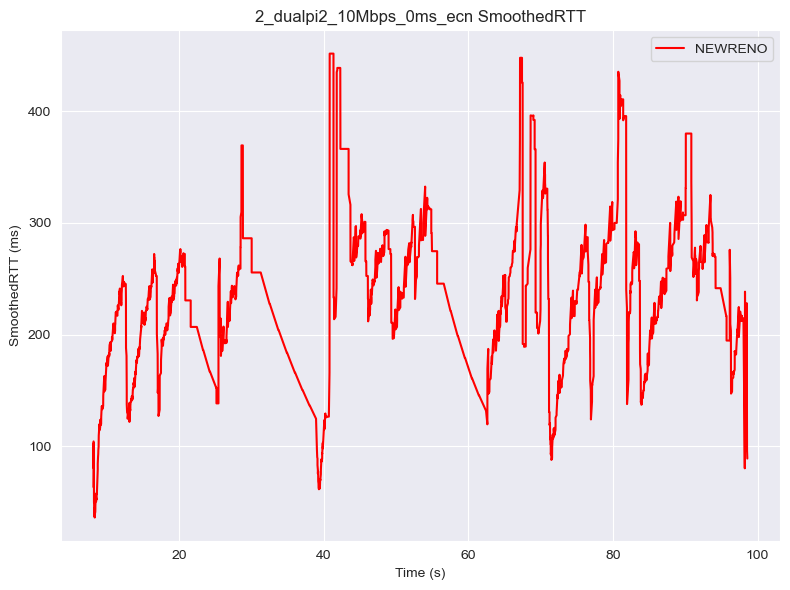

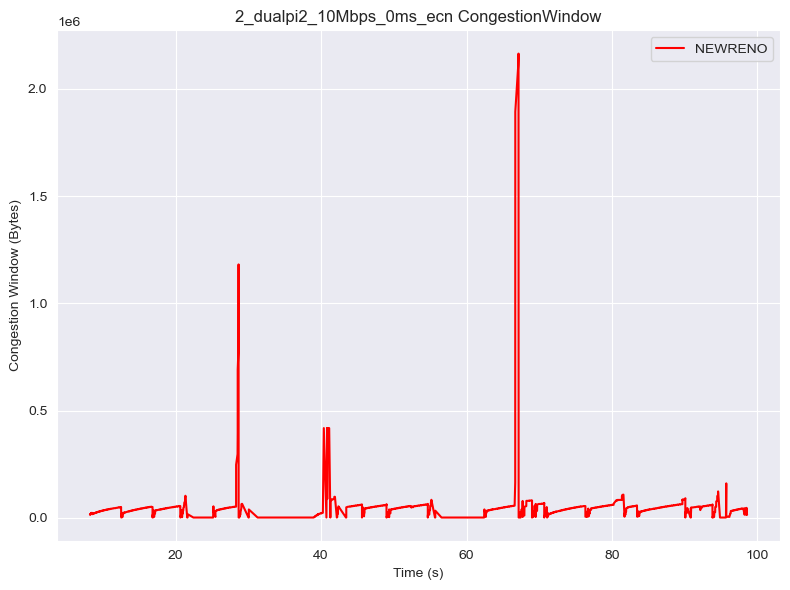


Start New Scenario
2_dualpi2_10Mbps_10ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_10Mbps_10ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_10Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_10Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_10Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
77            o   8.158823  192.168.1.3     50459  192.168.3.2        5102   
78            o   8.158947  192.168.1.3     50459  192.168.3.2        5102   
80            o   8.234842  192.168.1.3     50459  192.168.3.2        5102   
81            o   8.234955  192.168.1.3     50459  192.168.3.2        5102   
84            o   8.354170  192.168.1.3     50459  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
19296         o  

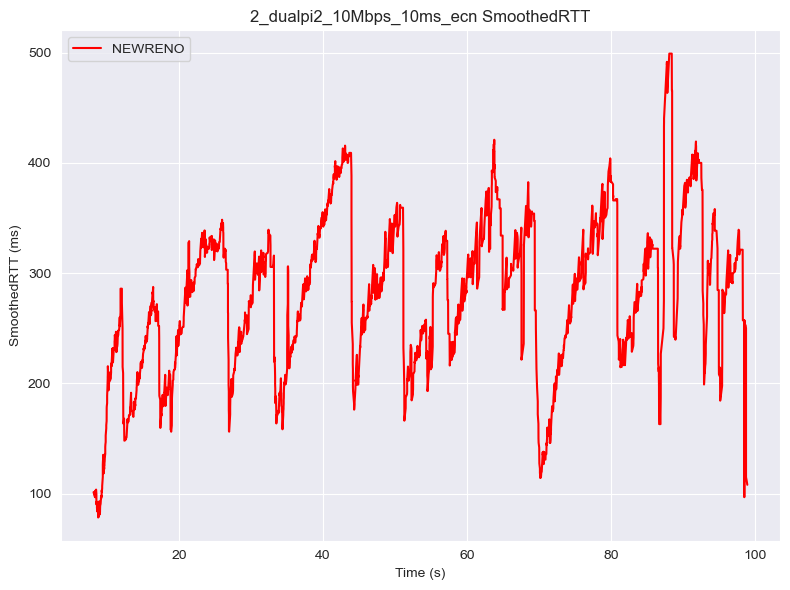

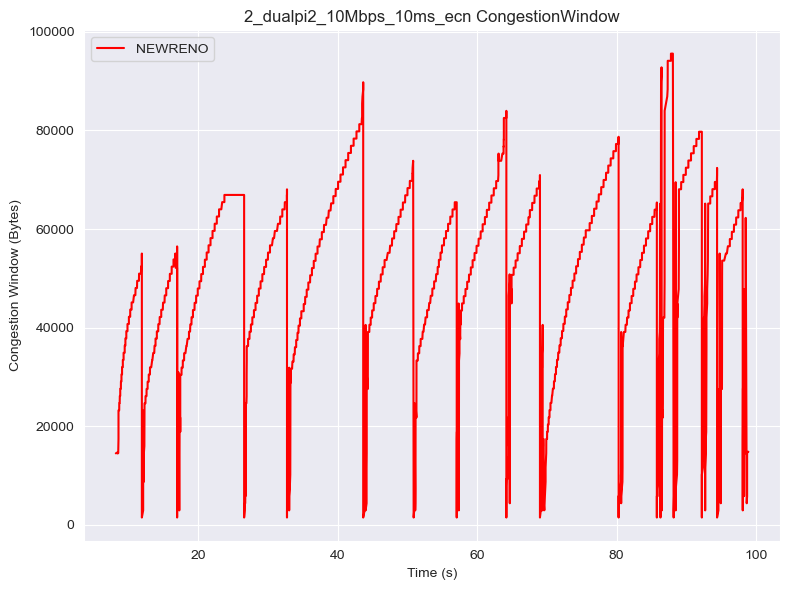


Start New Scenario
2_dualpi2_10Mbps_20ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_10Mbps_20ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_10Mbps_20ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_10Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_10Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
73            o   8.321502  192.168.1.3     59184  192.168.3.2        5102   
74            o   8.321671  192.168.1.3     59184  192.168.3.2        5102   
76            o   8.442911  192.168.1.3     59184  192.168.3.2        5102   
77            o   8.443033  192.168.1.3     59184  192.168.3.2        5102   
80            o   8.585417  192.168.1.3     59184  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
19251         o  

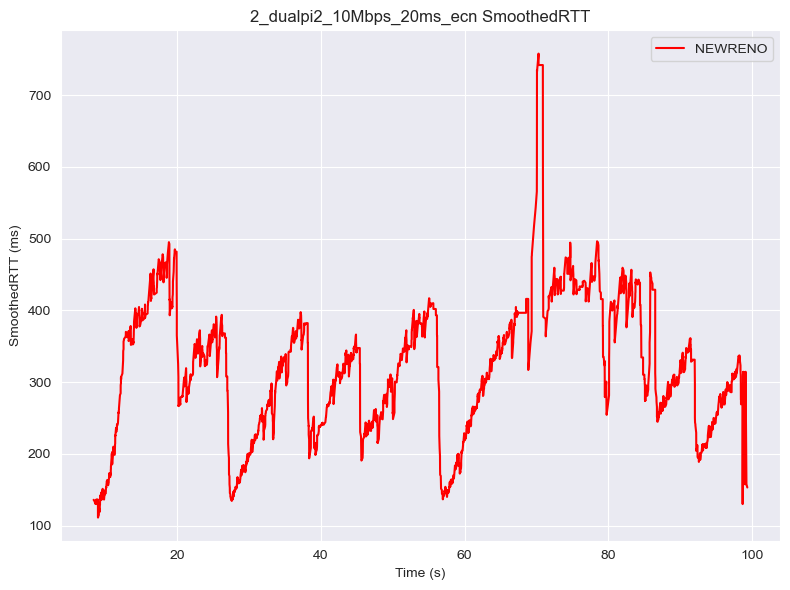

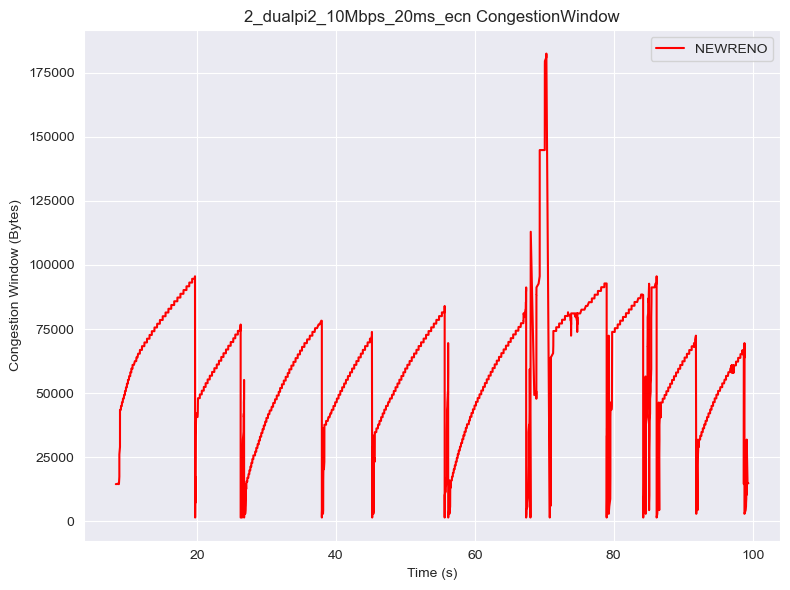


Start New Scenario
2_dualpi2_10Mbps_5ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_10Mbps_5ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_10Mbps_5ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_10Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_10Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
77            o   8.078425  192.168.1.3     59681  192.168.3.2        5102   
78            o   8.078557  192.168.1.3     59681  192.168.3.2        5102   
80            o   8.079378  192.168.1.3     59681  192.168.3.2        5102   
81            o   8.079490  192.168.1.3     59681  192.168.3.2        5102   
84            o   8.080442  192.168.1.3     59681  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
18690         o  98.22

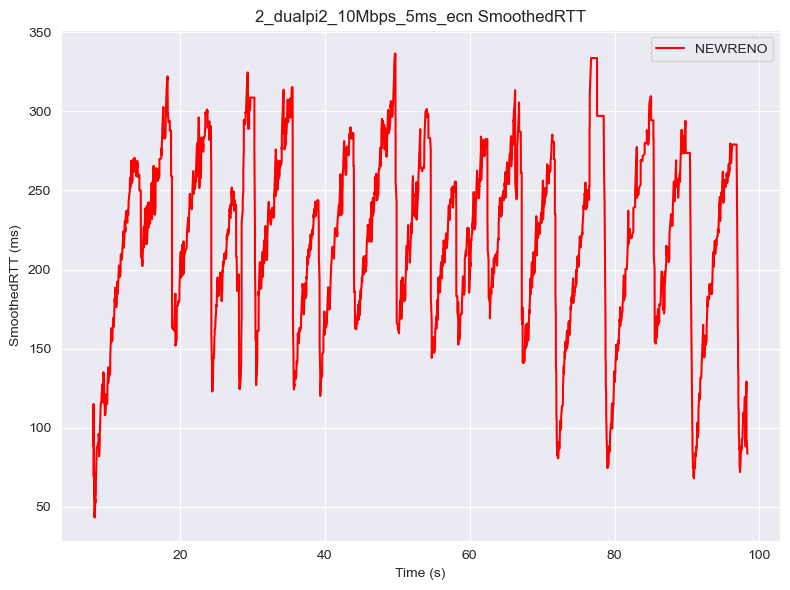

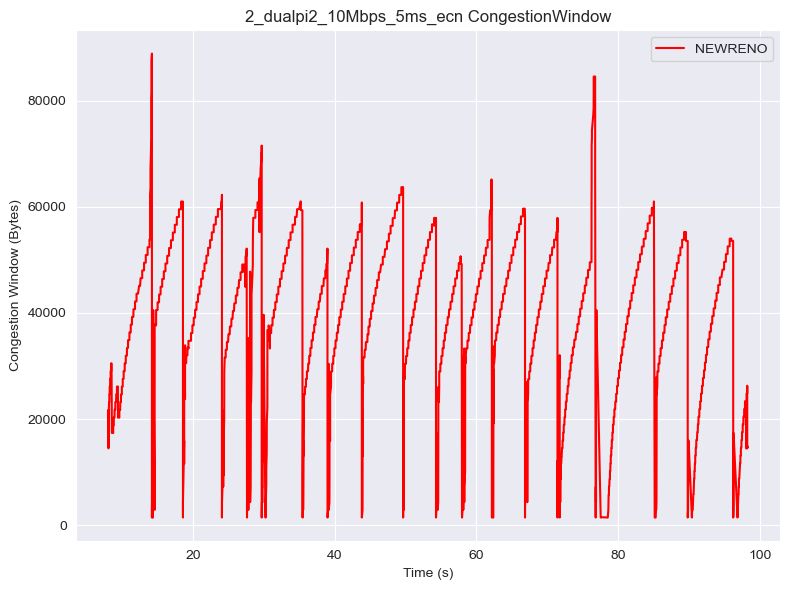


Start New Scenario
2_dualpi2_150Mbps_0ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_150Mbps_0ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_150Mbps_0ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_150Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_150Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
75             o   8.100227  192.168.1.3     13014  192.168.3.2        5102   
76             o   8.100360  192.168.1.3     13014  192.168.3.2        5102   
78             o   8.101596  192.168.1.3     13014  192.168.3.2        5102   
79             o   8.101758  192.168.1.3     13014  192.168.3.2        5102   
82             o   8.104885  192.168.1.3     13014  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
598960    

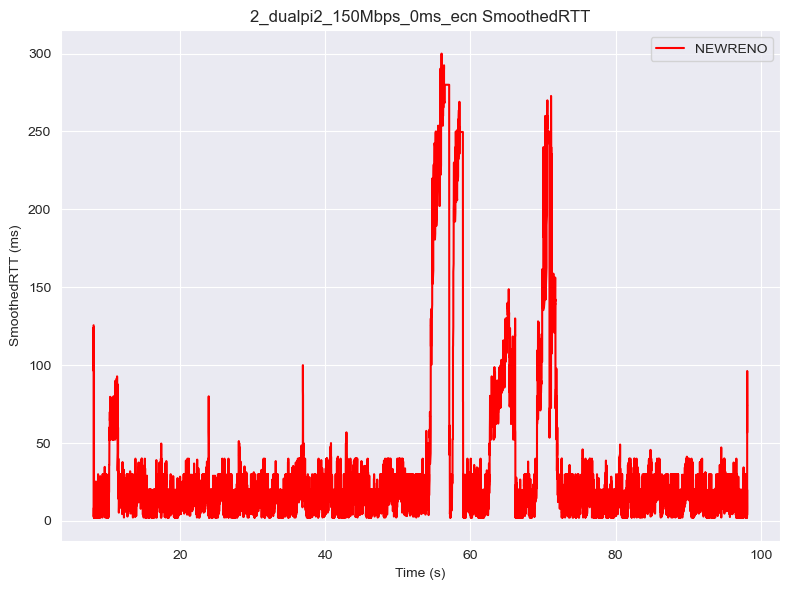

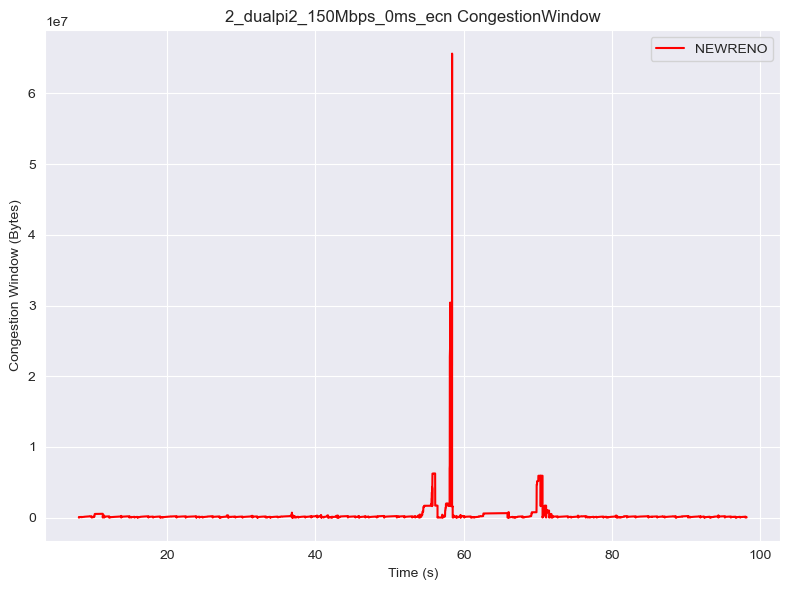


Start New Scenario
2_dualpi2_150Mbps_10ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_150Mbps_10ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_150Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_150Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_150Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
       Direction        Time      LocalIP LocalPort    ForeignIP ForeignPort  \
73             o    8.140736  192.168.1.3     24964  192.168.3.2        5102   
74             o    8.141039  192.168.1.3     24964  192.168.3.2        5102   
76             o    8.214227  192.168.1.3     24964  192.168.3.2        5102   
77             o    8.214336  192.168.1.3     24964  192.168.3.2        5102   
80             o    8.334043  192.168.1.3     24964  192.168.3.2        5102   
...          ...         ...          ...       ...          ...         ...  

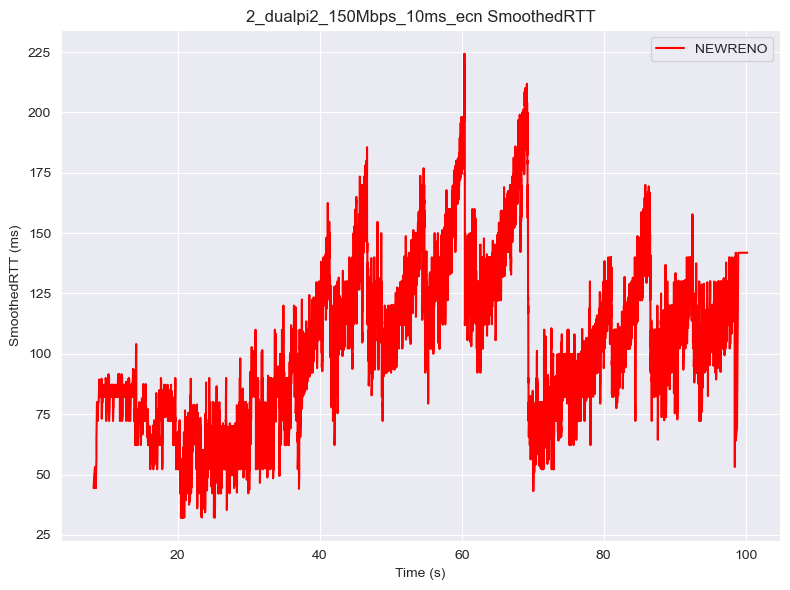

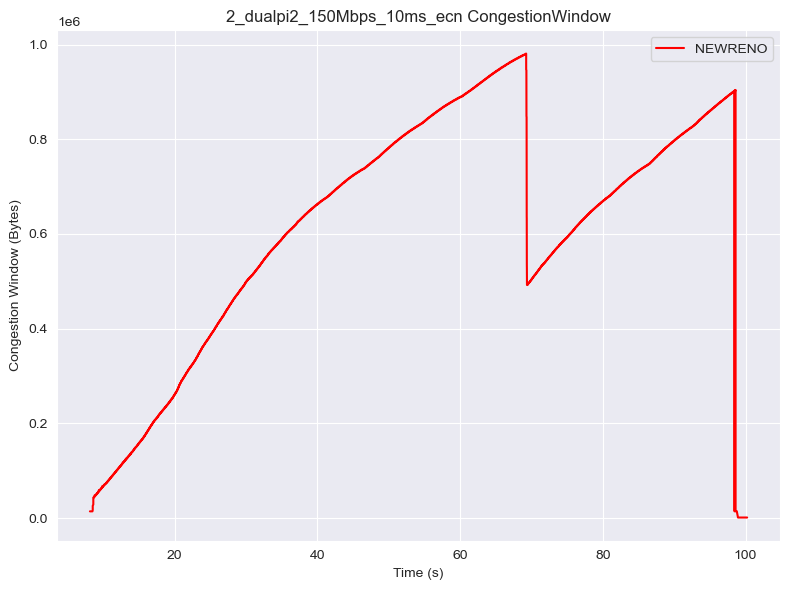


Start New Scenario
2_dualpi2_150Mbps_20ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_150Mbps_20ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_150Mbps_20ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_150Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_150Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
74             o   8.120827  192.168.1.3     12448  192.168.3.2        5102   
75             o   8.121006  192.168.1.3     12448  192.168.3.2        5102   
77             o   8.221269  192.168.1.3     12448  192.168.3.2        5102   
78             o   8.221429  192.168.1.3     12448  192.168.3.2        5102   
81             o   8.379769  192.168.1.3     12448  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
44834

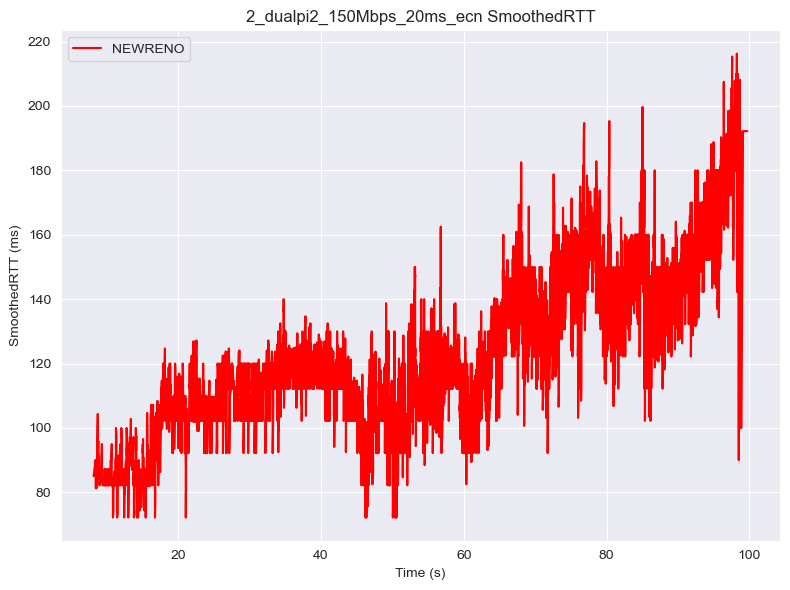

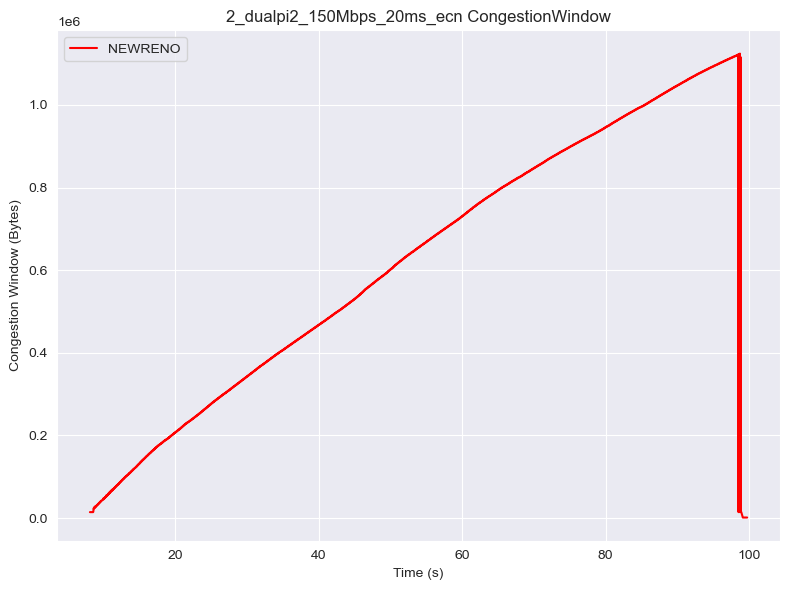


Start New Scenario
2_dualpi2_150Mbps_5ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_150Mbps_5ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_150Mbps_5ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_150Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_150Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
       Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
72             o   8.104953  192.168.1.3     62256  192.168.3.2        5102   
73             o   8.105166  192.168.1.3     62256  192.168.3.2        5102   
75             o   8.106214  192.168.1.3     62256  192.168.3.2        5102   
76             o   8.106243  192.168.1.3     62256  192.168.3.2        5102   
79             o   8.108781  192.168.1.3     62256  192.168.3.2        5102   
...          ...        ...          ...       ...          ...         ...   
607934    

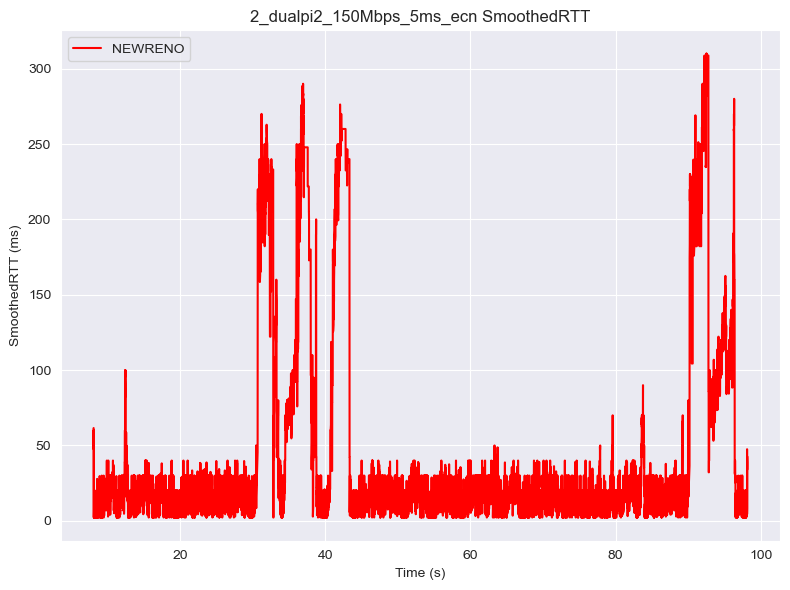

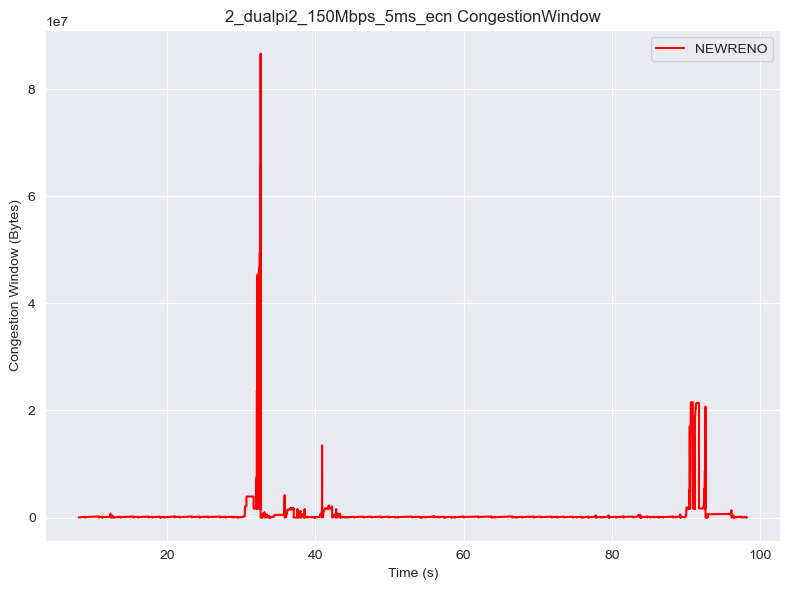


Start New Scenario
2_dualpi2_20Mbps_0ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_20Mbps_0ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
72            o   8.240468  192.168.1.3     59629  192.168.3.2        5102   
73            o   8.240518  192.168.1.3     59629  192.168.3.2        5102   
75            o   8.241320  192.168.1.3     59629  192.168.3.2        5102   
76            o   8.241352  192.168.1.3     59629  192.168.3.2        5102   
79            o   8.256349  192.168.1.3     59629  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
34228         o  98.45

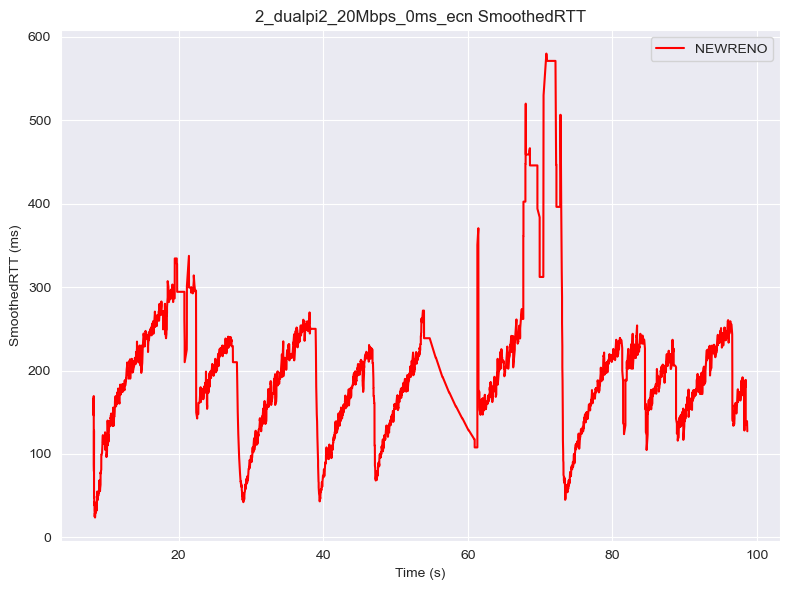

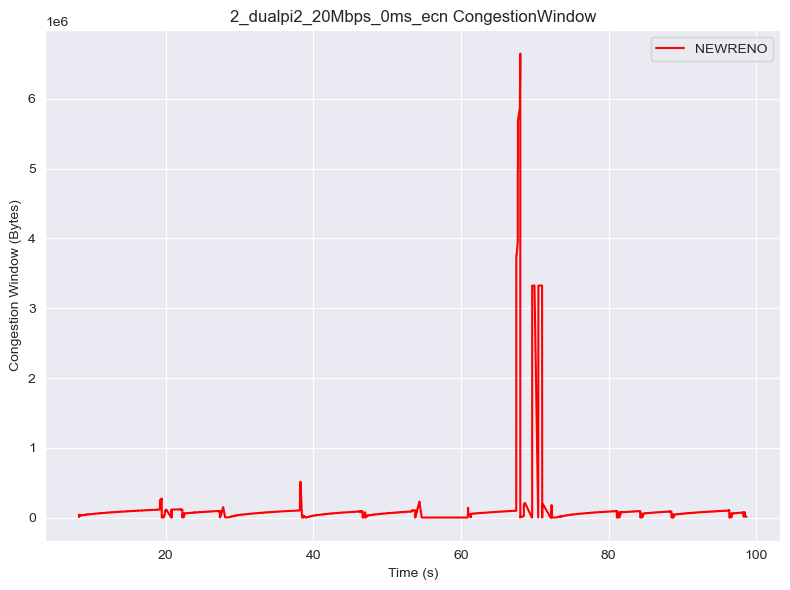


Start New Scenario
2_dualpi2_20Mbps_10ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_20Mbps_10ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_20Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_20Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_20Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
76            o   8.272659  192.168.1.3     24222  192.168.3.2        5102   
77            o   8.272896  192.168.1.3     24222  192.168.3.2        5102   
79            o   8.350332  192.168.1.3     24222  192.168.3.2        5102   
80            o   8.350453  192.168.1.3     24222  192.168.3.2        5102   
83            o   8.468598  192.168.1.3     24222  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
37823         o  

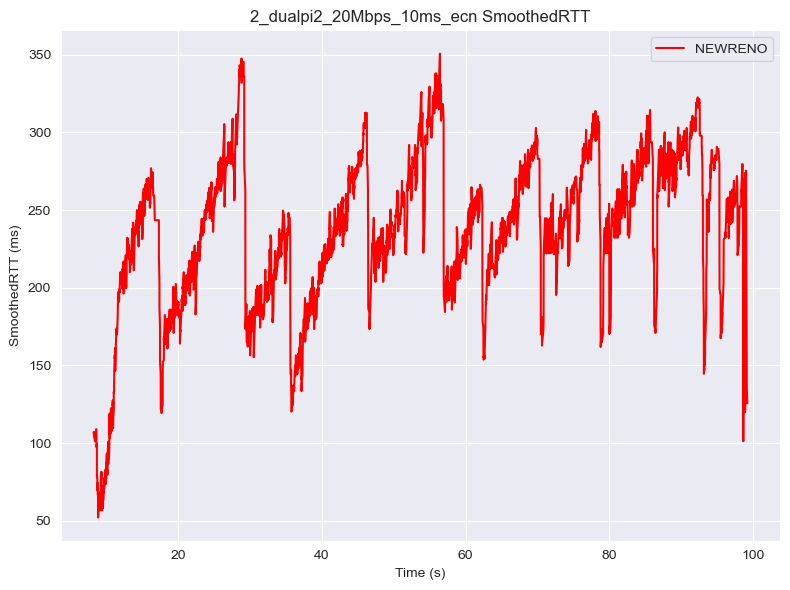

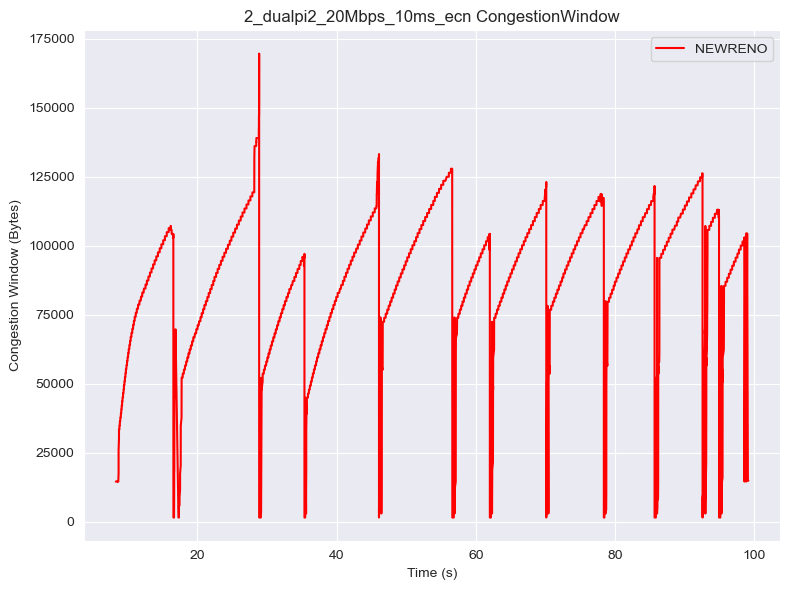


Start New Scenario
2_dualpi2_20Mbps_20ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_20Mbps_20ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_20Mbps_20ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_20Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_20Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
73            o   8.208459  192.168.1.3     47696  192.168.3.2        5102   
74            o   8.208603  192.168.1.3     47696  192.168.3.2        5102   
76            o   8.297491  192.168.1.3     47696  192.168.3.2        5102   
77            o   8.297966  192.168.1.3     47696  192.168.3.2        5102   
80            o   8.447328  192.168.1.3     47696  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
38817         o  

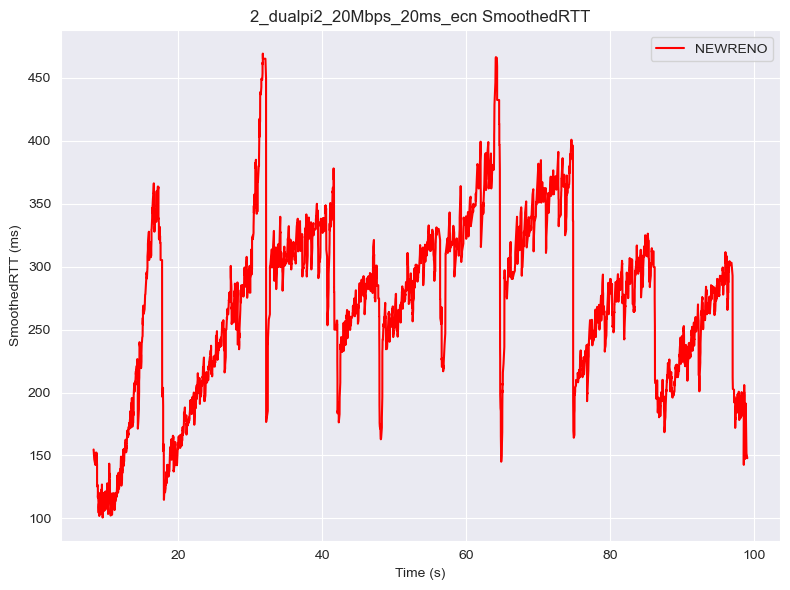

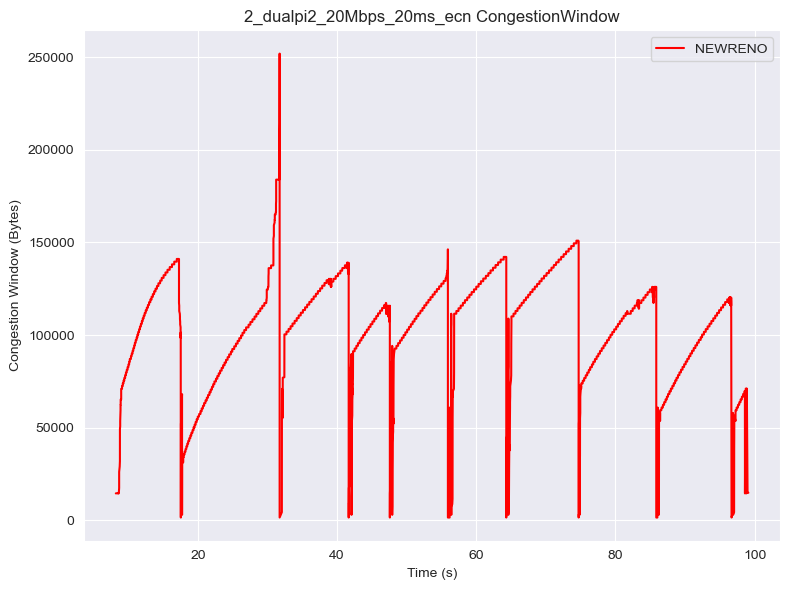


Start New Scenario
2_dualpi2_20Mbps_5ms_ecn
['../data/udp_data_2025-04-11/client1_data\\2_dualpi2_20Mbps_5ms_ecn_udp_newreno_src1.siftr.log', '../data/udp_data_2025-04-11/client2_data\\2_dualpi2_20Mbps_5ms_ecn_udp_dctcp_src2.siftr.log']
tcp_traffic ../data/udp_data_2025-04-11/client2_data\2_dualpi2_20Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-11/client2_data\2_dualpi2_20Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
      Direction       Time      LocalIP LocalPort    ForeignIP ForeignPort  \
74            o   8.260045  192.168.1.3     57213  192.168.3.2        5102   
75            o   8.260167  192.168.1.3     57213  192.168.3.2        5102   
77            o   8.260748  192.168.1.3     57213  192.168.3.2        5102   
78            o   8.260857  192.168.1.3     57213  192.168.3.2        5102   
81            o   8.262422  192.168.1.3     57213  192.168.3.2        5102   
...         ...        ...          ...       ...          ...         ...   
37632         o  98.33

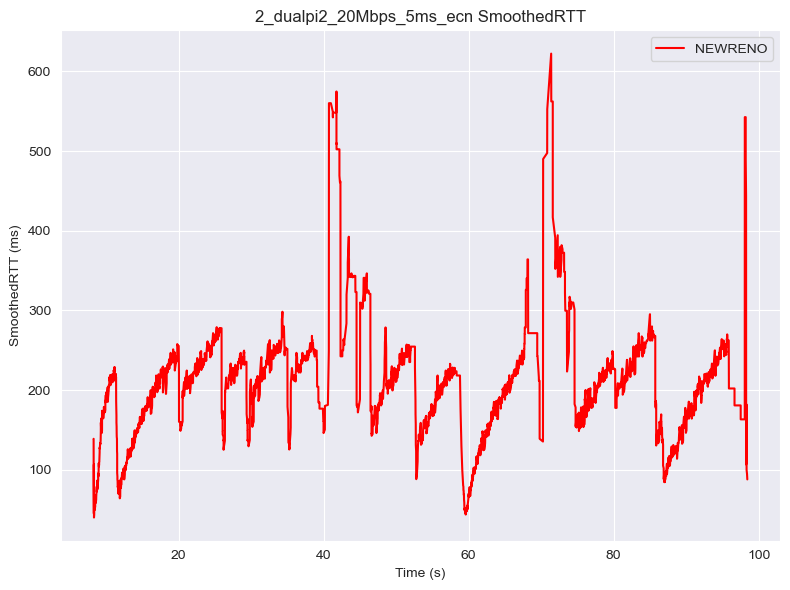

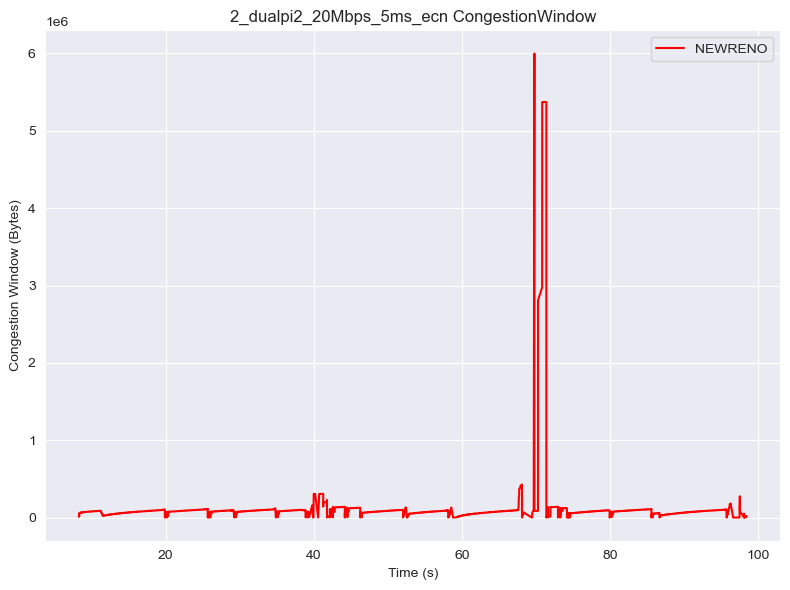

In [19]:
for scenario in unique_scenarios_dict.keys():

    print()
    print("Start New Scenario")
    print(scenario)
    print(unique_scenarios_dict[scenario])

    tcp_traffic = unique_scenarios_dict[scenario][1]

    print("tcp_traffic",tcp_traffic)


    ttf = get_dataframe_from_filepath(tcp_traffic)


    ttf = ttf[ttf['ForeignPort'] == "5102"]

    print(ttf)

    # Define paths
    paths = {
        "NEWRENO": ttf,
    }

    print_rtt_stats(paths=paths,scenario=scenario)
    save_rtt_stats(paths=paths,scenario=scenario,stats_directory=stats_directory)



    plot_siftr_graph(paths=paths,
                    ycolumn="SmoothedRTT",
                    title=f"{scenario} SmoothedRTT",
                    xlabel="Time (s)",
                    ylabel="SmoothedRTT (ms)",
                    filename=f'{scenario}_SmoothedRTT',
                    graph_directory=graph_directory,
    )




    plot_siftr_graph(paths=paths,
                    ycolumn="CongestionWindow",
                    title=f"{scenario} CongestionWindow",
                    xlabel="Time (s)",
                    ylabel="Congestion Window (Bytes)",
                    filename=f'{scenario}_CWND',
                    graph_directory=graph_directory,
    )
